# 02. Tokenizer Baselines

Purpose: establish non-neural D1/D2 tokenizer baselines before fitting
any VQ-family model.

Reusable baseline fit/evaluation logic lives in `kairos.experiments.shape_tokenizer.baselines`.

## Baseline Contract

- Fit only on the time-based split fixed in the protocol JSON: daily datasets use `split` (train 2005–2016), minute datasets use `split_minute` (train 2025-07~2026-01, fixed 2026-07-06 because provider minute history starts 2025-07).
- Use `01_shape_feature_validation.ipynb` artifacts as the only input; raw OHLCV is not persisted here.
- D2 merged datasets (`d2_kr-kospi-kosdaq_daily`, `d2_kr-kospi-kosdaq_1m`) concatenate component D1 shape rows sorted by timestamp; daily and minute rows are never mixed in one dataset.
- Exclude zero-range rows from fitting and reconstruction metrics.
- Compare boundary policy A/B:
  - `include_boundary`: winsorized logit shape core keeps boundary candles.
  - `exclude_boundary`: removes boundary candles before fitting/evaluation.
- Compare k-means, Gaussian mixture, and hand-crafted lambda bins.
- Run seeds `7`, `17`, and `37`.

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

from kairos.experiments.shape_tokenizer.baselines import (
    BOUNDARY_POLICIES,
    CODEBOOK_SIZES,
    FEATURE_INPUTS,
    MERGED_FEATURE_INPUTS,
    MIN_TRAIN_ROWS,
    SEEDS,
    MergedFeatureInput,
    build_baseline_config,
    build_merged_baseline_config,
    component_feature_runs,
    dataset_interval,
    evaluate_baselines,
    latest_feature_run,
    read_merged_shape_rows,
    read_shape_rows,
    shape_rows_for_boundary_policy,
    split_masks,
)
from kairos.experiments.artifacts import config_hash, find_project_root, strip_hash_excluded, to_jsonable, write_csv, write_json
from kairos.experiments.protocol import PHASE_01_ID, RESEARCH_NAME, STEP_02_BASELINE_ID, split_protocol_for_interval

PROJECT_ROOT = find_project_root()
RUNS_ROOT = PROJECT_ROOT / "notebooks" / "runs" / RESEARCH_NAME
SOURCE_NOTEBOOK = "notebooks/candlestick-shape-quantization/02_tokenizer_baselines.ipynb"
FIGURE_EXPLANATION = (
    PROJECT_ROOT
    / "notebooks"
    / "runs"
    / RESEARCH_NAME
    / PHASE_01_ID
    / "step-01-shape-feature-validation"
    / "FIGURE_EXPLANATION.md"
)

ALL_BASELINE_INPUTS = FEATURE_INPUTS + MERGED_FEATURE_INPUTS

PROJECT_ROOT

PosixPath('/Users/choeseoggyu/portfolio/kairos')

## Inputs


In [2]:
[to_jsonable(feature_input) for feature_input in ALL_BASELINE_INPUTS]

[{'dataset_id': 'd1_kospi_daily',
  'feature_cfg_hash': '5628106a',
  'symbol': 'KOSPI',
  'provider': 'kiwoom'},
 {'dataset_id': 'd1_kospi_1m',
  'feature_cfg_hash': 'd7a389ba',
  'symbol': 'KOSPI',
  'provider': 'kiwoom'},
 {'dataset_id': 'd1_kosdaq_daily',
  'feature_cfg_hash': 'd17b71e2',
  'symbol': 'KOSDAQ',
  'provider': 'kiwoom'},
 {'dataset_id': 'd1_kosdaq_1m',
  'feature_cfg_hash': 'b2699d03',
  'symbol': 'KOSDAQ',
  'provider': 'kiwoom'},
 {'dataset_id': 'd1_nasdaq_daily',
  'feature_cfg_hash': 'a8489a0e',
  'symbol': 'NASDAQ',
  'provider': 'kis'},
 {'dataset_id': 'd1_spx_daily',
  'feature_cfg_hash': 'e28b4a09',
  'symbol': 'SPX',
  'provider': 'kis'},
 {'dataset_id': 'd2_kr-kospi-kosdaq_daily',
  'stage': 'D2',
  'components': [{'dataset_id': 'd1_kospi_daily',
    'feature_cfg_hash': '5628106a',
    'symbol': 'KOSPI',
    'provider': 'kiwoom'},
   {'dataset_id': 'd1_kosdaq_daily',
    'feature_cfg_hash': 'd17b71e2',
    'symbol': 'KOSDAQ',
    'provider': 'kiwoom'}]},
 {'

## Artifact Writers


In [3]:
def make_baseline_figure(rows: list[dict[str, Any]], path: Path) -> None:
    if not rows:
        return
    labels = [
        f"{row['boundary_policy']}\n{row['model']}\nK={row['codebook_size']}"
        for row in rows
    ]
    values = [row["reconstruction_mse"] for row in rows]
    fig, ax = plt.subplots(figsize=(max(10, len(rows) * 0.75), 4.8))
    ax.bar(labels, values)
    ax.set_ylabel("MSE in (s1, s2)")
    ax.set_title("Tokenizer baseline reconstruction error by boundary policy")
    ax.tick_params(axis="x", rotation=60)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def policy_row_counts(rows: list[dict[str, Any]], split) -> dict[str, int]:
    masks = split_masks(rows, split=split)
    return {
        "finite_shape_rows": len(rows),
        "train_rows": int(masks["train"].sum()),
        "validation_rows": int(masks["validation"].sum()),
        "test_rows": int(masks["test"].sum()),
    }


def data_quality_warnings(feature_input, source_rows: list[dict[str, Any]], boundary_count: int) -> list[str]:
    warnings: list[str] = []
    if feature_input.dataset_id.endswith("_1m") and feature_input.provider == "kis" and len(source_rows) <= 200:
        warnings.append("kis_minute_provider_limited_rows")
    if source_rows and boundary_count / len(source_rows) > 0.5:
        warnings.append("boundary_heavy_distribution")
    if not source_rows:
        warnings.append("empty_feature_input")
    return warnings


def load_baseline_input(feature_input) -> tuple[list[dict[str, Any]], dict[str, Any], Any]:
    """source rows, config, input run 경로 표현을 dataset 종류(D1/D2)에 맞게 돌려준다."""
    if isinstance(feature_input, MergedFeatureInput):
        input_run_dirs = component_feature_runs(RUNS_ROOT, feature_input)
        source_rows = read_merged_shape_rows(input_run_dirs)
        config = build_merged_baseline_config(feature_input, input_run_dirs)
        input_run_repr = {
            dataset_id: run_dir.as_posix() for dataset_id, run_dir in input_run_dirs.items()
        }
        return source_rows, config, input_run_repr
    input_run_dir = latest_feature_run(RUNS_ROOT, feature_input)
    source_rows = read_shape_rows(input_run_dir)
    config = build_baseline_config(feature_input, input_run_dir)
    return source_rows, config, input_run_dir.as_posix()


def evaluate_feature_input(feature_input, *, seed: int) -> dict[str, Any]:
    source_rows, config, input_run_repr = load_baseline_input(feature_input)
    split = split_protocol_for_interval(dataset_interval(feature_input.dataset_id))
    zero_range_count = sum(1 for row in source_rows if row["is_zero_range"])
    boundary_count = sum(1 for row in source_rows if row["is_boundary"])

    config = config | {
        "figure_explanation": FIGURE_EXPLANATION.relative_to(PROJECT_ROOT).as_posix(),
        "boundary_policy_comparison": list(BOUNDARY_POLICIES),
    }
    cfg_hash = config_hash(config)
    started_at = datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S")
    cfg_dir = RUNS_ROOT / PHASE_01_ID / STEP_02_BASELINE_ID / feature_input.dataset_id / f"cfg-{cfg_hash}"
    run_dir = cfg_dir / f"run-{started_at}_seed-{seed}"
    tables_dir = run_dir / "tables"
    figures_dir = run_dir / "figures"
    tables_dir.mkdir(parents=True, exist_ok=False)
    figures_dir.mkdir(parents=True, exist_ok=True)

    write_json(cfg_dir / "config.json", strip_hash_excluded(to_jsonable(config)))
    write_json(run_dir / "experiment_config.json", config | {"seed": seed, "started_at": started_at})

    baseline_metrics: list[dict[str, Any]] = []
    baseline_rows: list[dict[str, Any]] = []
    policy_results: dict[str, dict[str, Any]] = {}

    for boundary_policy in BOUNDARY_POLICIES:
        rows = shape_rows_for_boundary_policy(source_rows, boundary_policy=boundary_policy)
        counts = policy_row_counts(rows, split)
        boundary_excluded_count = sum(
            1 for row in source_rows if row["is_boundary"] and not row["is_zero_range"]
        ) if boundary_policy == "exclude_boundary" else 0

        policy_status = "ok"
        skip_reason = None
        if counts["train_rows"] < MIN_TRAIN_ROWS:
            policy_status = "skipped"
            skip_reason = f"insufficient train rows: {counts['train_rows']} < {MIN_TRAIN_ROWS}"
        else:
            metrics_for_policy, rows_for_policy = evaluate_baselines(rows, seed=seed, split=split)
            for row in metrics_for_policy:
                baseline_metrics.append({"boundary_policy": boundary_policy, **row})
            for row in rows_for_policy:
                baseline_rows.append({"boundary_policy": boundary_policy, **row})

        policy_results[boundary_policy] = {
            "status": policy_status,
            "skip_reason": skip_reason,
            "row_counts": counts | {"boundary_excluded_count": boundary_excluded_count},
            "model_count": 0 if policy_status == "skipped" else len(CODEBOOK_SIZES) * 2 + 1,
        }

    if baseline_rows:
        make_baseline_figure(baseline_rows, figures_dir / "baseline_reconstruction_mse.png")

    status = "ok" if any(result["status"] == "ok" for result in policy_results.values()) else "skipped"
    skip_reason = None if status == "ok" else "; ".join(
        f"{policy}: {result['skip_reason']}" for policy, result in policy_results.items()
    )

    metrics = {
        "dataset_id": feature_input.dataset_id,
        "status": status,
        "skip_reason": skip_reason,
        "seed": seed,
        "split_section": "split_minute" if dataset_interval(feature_input.dataset_id) == "1m" else "split",
        "input_feature_run": input_run_repr,
        "figure_explanation": FIGURE_EXPLANATION.relative_to(PROJECT_ROOT).as_posix(),
        "row_counts": {
            "source_rows": len(source_rows),
            "zero_range_count": zero_range_count,
            "boundary_count": boundary_count,
        },
        "data_quality_warnings": data_quality_warnings(feature_input, source_rows, boundary_count),
        "boundary_policy_results": policy_results,
        "required_tokenizer_metrics": {
            "reconstruction_error_recorded": bool(baseline_metrics),
            "token_entropy_recorded": bool(baseline_metrics),
            "effective_vocab_size_recorded": bool(baseline_metrics),
            "dead_token_count_recorded": bool(baseline_metrics),
            "excluded_special_rows_recorded": True,
            "boundary_ab_comparison_recorded": len(policy_results) == len(BOUNDARY_POLICIES),
        },
        "baselines": baseline_metrics,
        "leakage_checks": {
            "fit_on_train_split_only": True,
            "scaler_fit_on_train_split_only": True,
            "random_split_forbidden": True,
            "raw_ohlcv_persisted": False,
        },
    }
    write_json(run_dir / "metrics.json", metrics)
    write_csv(tables_dir / "baseline_summary.csv", baseline_rows)

    manifest = {
        "research": RESEARCH_NAME,
        "phase": PHASE_01_ID,
        "step": STEP_02_BASELINE_ID,
        "dataset_id": feature_input.dataset_id,
        "cfg_hash": cfg_hash,
        "seed": seed,
        "status": status,
        "created_at_utc": datetime.now(timezone.utc).replace(microsecond=0).isoformat(),
        "source_notebook": SOURCE_NOTEBOOK,
        "input_feature_run": input_run_repr,
        "figure_explanation": FIGURE_EXPLANATION.relative_to(PROJECT_ROOT).as_posix(),
        "raw_ohlcv_persisted": False,
        "output_files": [
            "experiment_config.json",
            "metrics.json",
            "manifest.json",
            "tables/baseline_summary.csv",
        ]
        + (["figures/baseline_reconstruction_mse.png"] if status == "ok" else []),
        "notes": [
            "Baselines consume derived shape features only.",
            "Boundary-heavy datasets are evaluated with include_boundary and exclude_boundary policies.",
            "Minute datasets use the split_minute protocol section fixed on 2026-07-06.",
            "D2 merged datasets concatenate component D1 shape rows sorted by timestamp.",
        ],
    }
    write_json(run_dir / "manifest.json", manifest)
    return {
        "dataset_id": feature_input.dataset_id,
        "status": status,
        "skip_reason": skip_reason,
        "cfg_hash": cfg_hash,
        "seed": seed,
        "run_dir": run_dir.as_posix(),
        "policy_results": policy_results,
        "model_count": len(baseline_metrics),
    }

## Execute Baselines


In [4]:
RUN_RESULTS = [
    evaluate_feature_input(feature_input, seed=seed)
    for feature_input in ALL_BASELINE_INPUTS
    for seed in SEEDS
]
RUN_RESULTS

[{'dataset_id': 'd1_kospi_daily',
  'status': 'ok',
  'skip_reason': None,
  'cfg_hash': 'd35d74f4',
  'seed': 7,
  'run_dir': '/Users/choeseoggyu/portfolio/kairos/notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_daily/cfg-d35d74f4/run-20260706-150235_seed-7',
  'policy_results': {'include_boundary': {'status': 'ok',
    'skip_reason': None,
    'row_counts': {'finite_shape_rows': 9420,
     'train_rows': 2976,
     'validation_rows': 981,
     'test_rows': 1348,
     'boundary_excluded_count': 0},
    'model_count': 7},
   'exclude_boundary': {'status': 'ok',
    'skip_reason': None,
    'row_counts': {'finite_shape_rows': 6838,
     'train_rows': 2379,
     'validation_rows': 814,
     'test_rows': 1057,
     'boundary_excluded_count': 2582},
    'model_count': 7}},
  'model_count': 14},
 {'dataset_id': 'd1_kospi_daily',
  'status': 'ok',
  'skip_reason': None,
  'cfg_hash': 'd35d74f4',
  'seed': 17,
  'run_dir': '/Users/choe

## Acceptance Checks


In [5]:
assert len(RUN_RESULTS) == len(ALL_BASELINE_INPUTS) * len(SEEDS)

expected_fit_datasets = {
    "d1_kospi_daily",
    "d1_kosdaq_daily",
    "d1_nasdaq_daily",
    "d1_spx_daily",
    "d1_kospi_1m",
    "d1_kosdaq_1m",
    "d2_kr-kospi-kosdaq_daily",
    "d2_kr-kospi-kosdaq_1m",
}
assert {result["dataset_id"] for result in RUN_RESULTS} == expected_fit_datasets

assert all(result["status"] == "ok" for result in RUN_RESULTS)
assert all(
    result["policy_results"][policy]["status"] == "ok"
    for result in RUN_RESULTS
    for policy in BOUNDARY_POLICIES
)
assert all(
    result["model_count"] == len(BOUNDARY_POLICIES) * (len(CODEBOOK_SIZES) * 2 + 1)
    for result in RUN_RESULTS
)
assert all(
    result["policy_results"][policy]["row_counts"]["train_rows"] >= MIN_TRAIN_ROWS
    for result in RUN_RESULTS
    for policy in BOUNDARY_POLICIES
)

d2_results = [result for result in RUN_RESULTS if result["dataset_id"].startswith("d2_")]
assert len(d2_results) == 2 * len(SEEDS)

RUN_RESULTS

[{'dataset_id': 'd1_kospi_daily',
  'status': 'ok',
  'skip_reason': None,
  'cfg_hash': 'd35d74f4',
  'seed': 7,
  'run_dir': '/Users/choeseoggyu/portfolio/kairos/notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_daily/cfg-d35d74f4/run-20260706-150235_seed-7',
  'policy_results': {'include_boundary': {'status': 'ok',
    'skip_reason': None,
    'row_counts': {'finite_shape_rows': 9420,
     'train_rows': 2976,
     'validation_rows': 981,
     'test_rows': 1348,
     'boundary_excluded_count': 0},
    'model_count': 7},
   'exclude_boundary': {'status': 'ok',
    'skip_reason': None,
    'row_counts': {'finite_shape_rows': 6838,
     'train_rows': 2379,
     'validation_rows': 814,
     'test_rows': 1057,
     'boundary_excluded_count': 2582},
    'model_count': 7}},
  'model_count': 14},
 {'dataset_id': 'd1_kospi_daily',
  'status': 'ok',
  'skip_reason': None,
  'cfg_hash': 'd35d74f4',
  'seed': 17,
  'run_dir': '/Users/choe

## Cluster Shape Atlas

`kmeans K=32`가 찾은 각 cluster를 캔들 형태로 시각화한다.

- baseline과 동일한 절차(train split에서 scaler·k-means fit, seed 고정)로 codebook을 다시 fit하므로, 위 `RUN_RESULTS`에 기록된 token 할당과 일치한다.
- 각 prototype `(s1, s2)`를 sigmoid로 되돌려 `(lambda_o, lambda_c)`를 얻고, low=0, high=1로 정규화한 캔들 glyph로 그린다. 세로선은 range(low~high), body는 open~close이며 양봉은 red, 음봉은 blue다.
- 각 칸의 제목은 token id, 전체 row 대비 token 점유율, prototype의 `(lambda_o, lambda_c)`이고 점유율 내림차순으로 정렬한다.
- shape core만 사용하므로 캔들의 절대 크기(`rel_range` 등)는 표현하지 않는다. `lambda`가 0 또는 1에 붙은 prototype이 boundary candle을 흡수한 token이다.
- figure는 seed 7 run의 `figures/` 아래에 `token-shapes__<dataset>__kmeans__k32-<boundary-policy>__seed-7.png`로 저장한다.

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_daily/cfg-d35d74f4/run-20260706-150235_seed-7/figures/token-shapes__d1_kospi_daily__kmeans__k32-include_boundary__seed-7.png


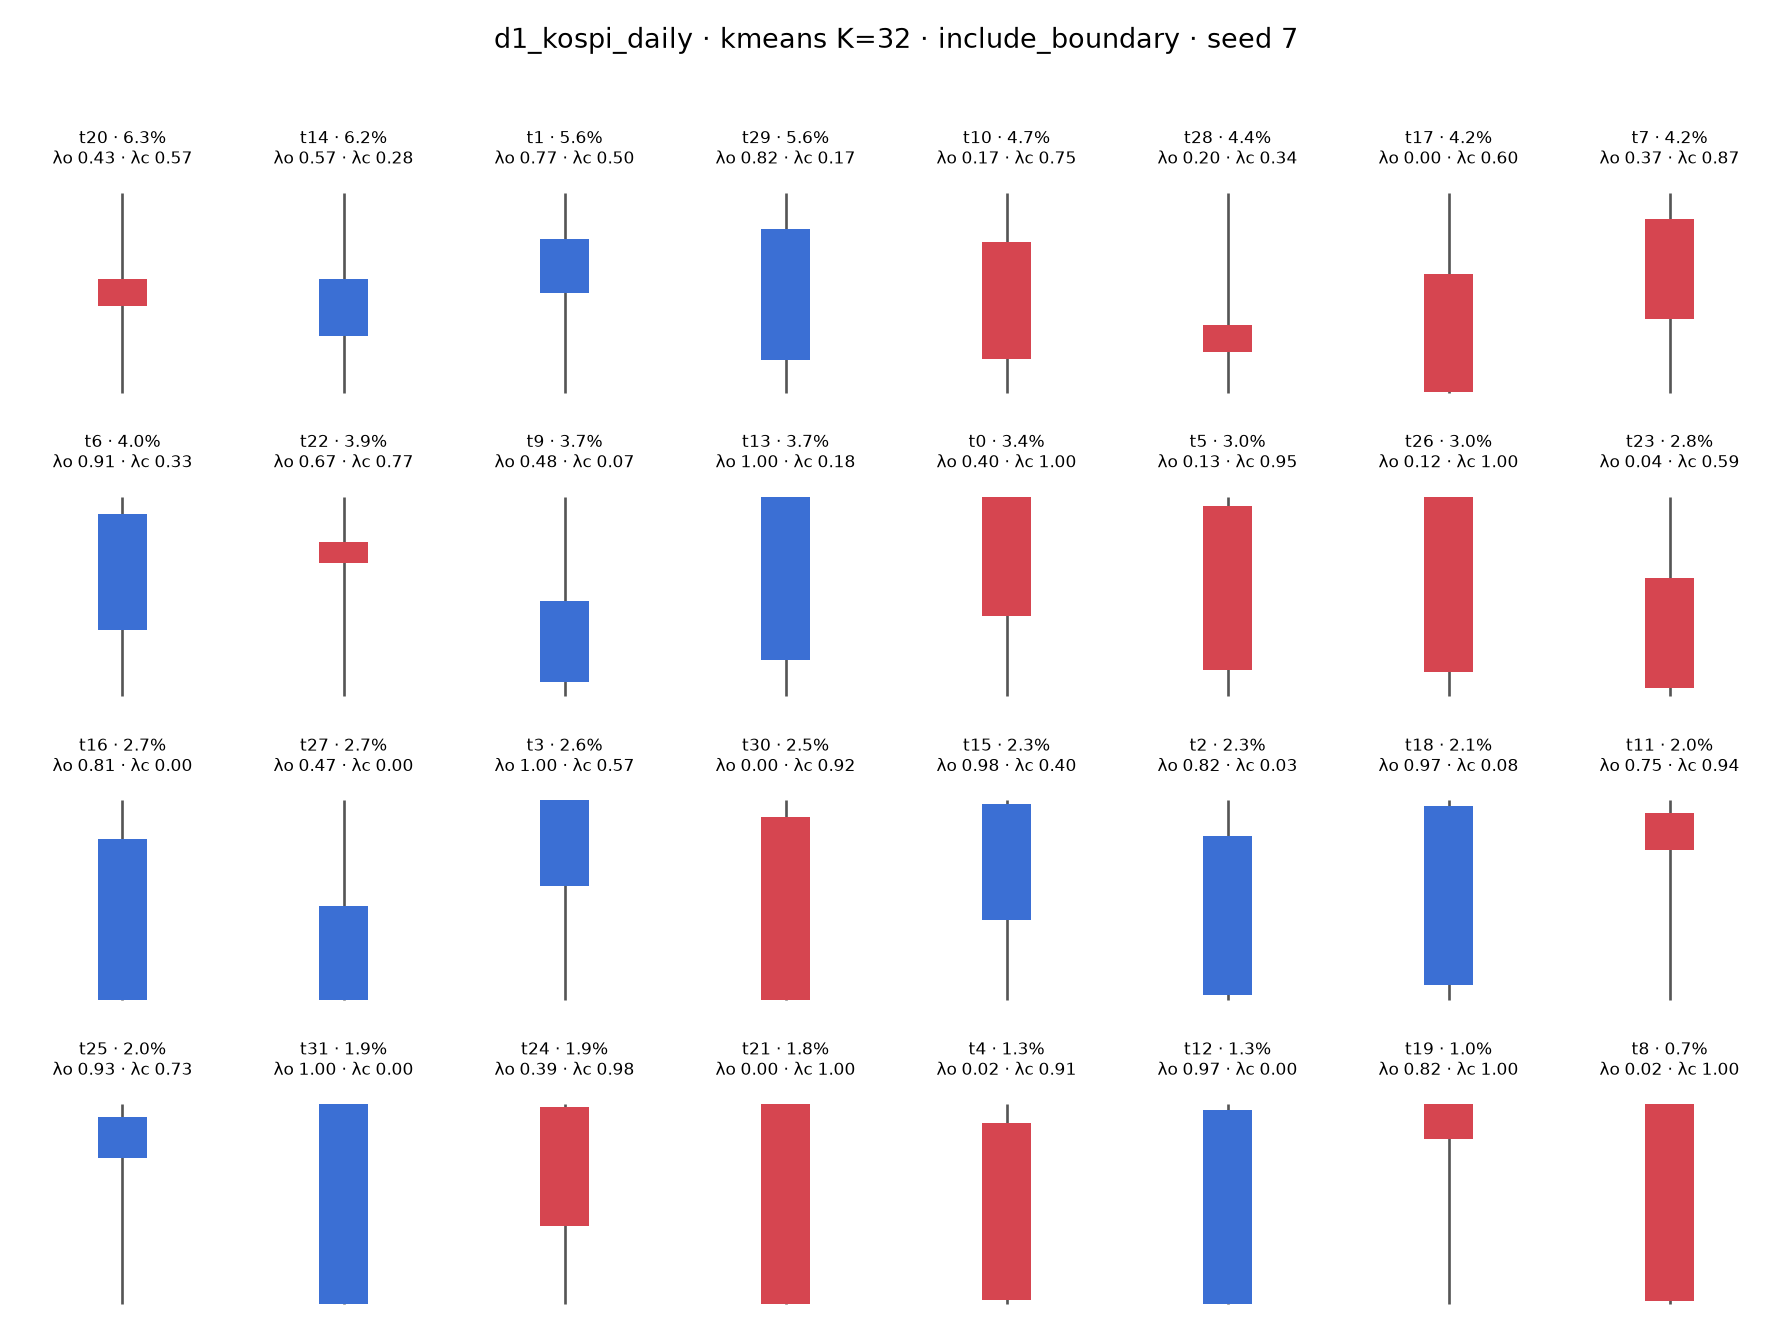

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_daily/cfg-d35d74f4/run-20260706-150235_seed-7/figures/token-shapes__d1_kospi_daily__kmeans__k32-exclude_boundary__seed-7.png


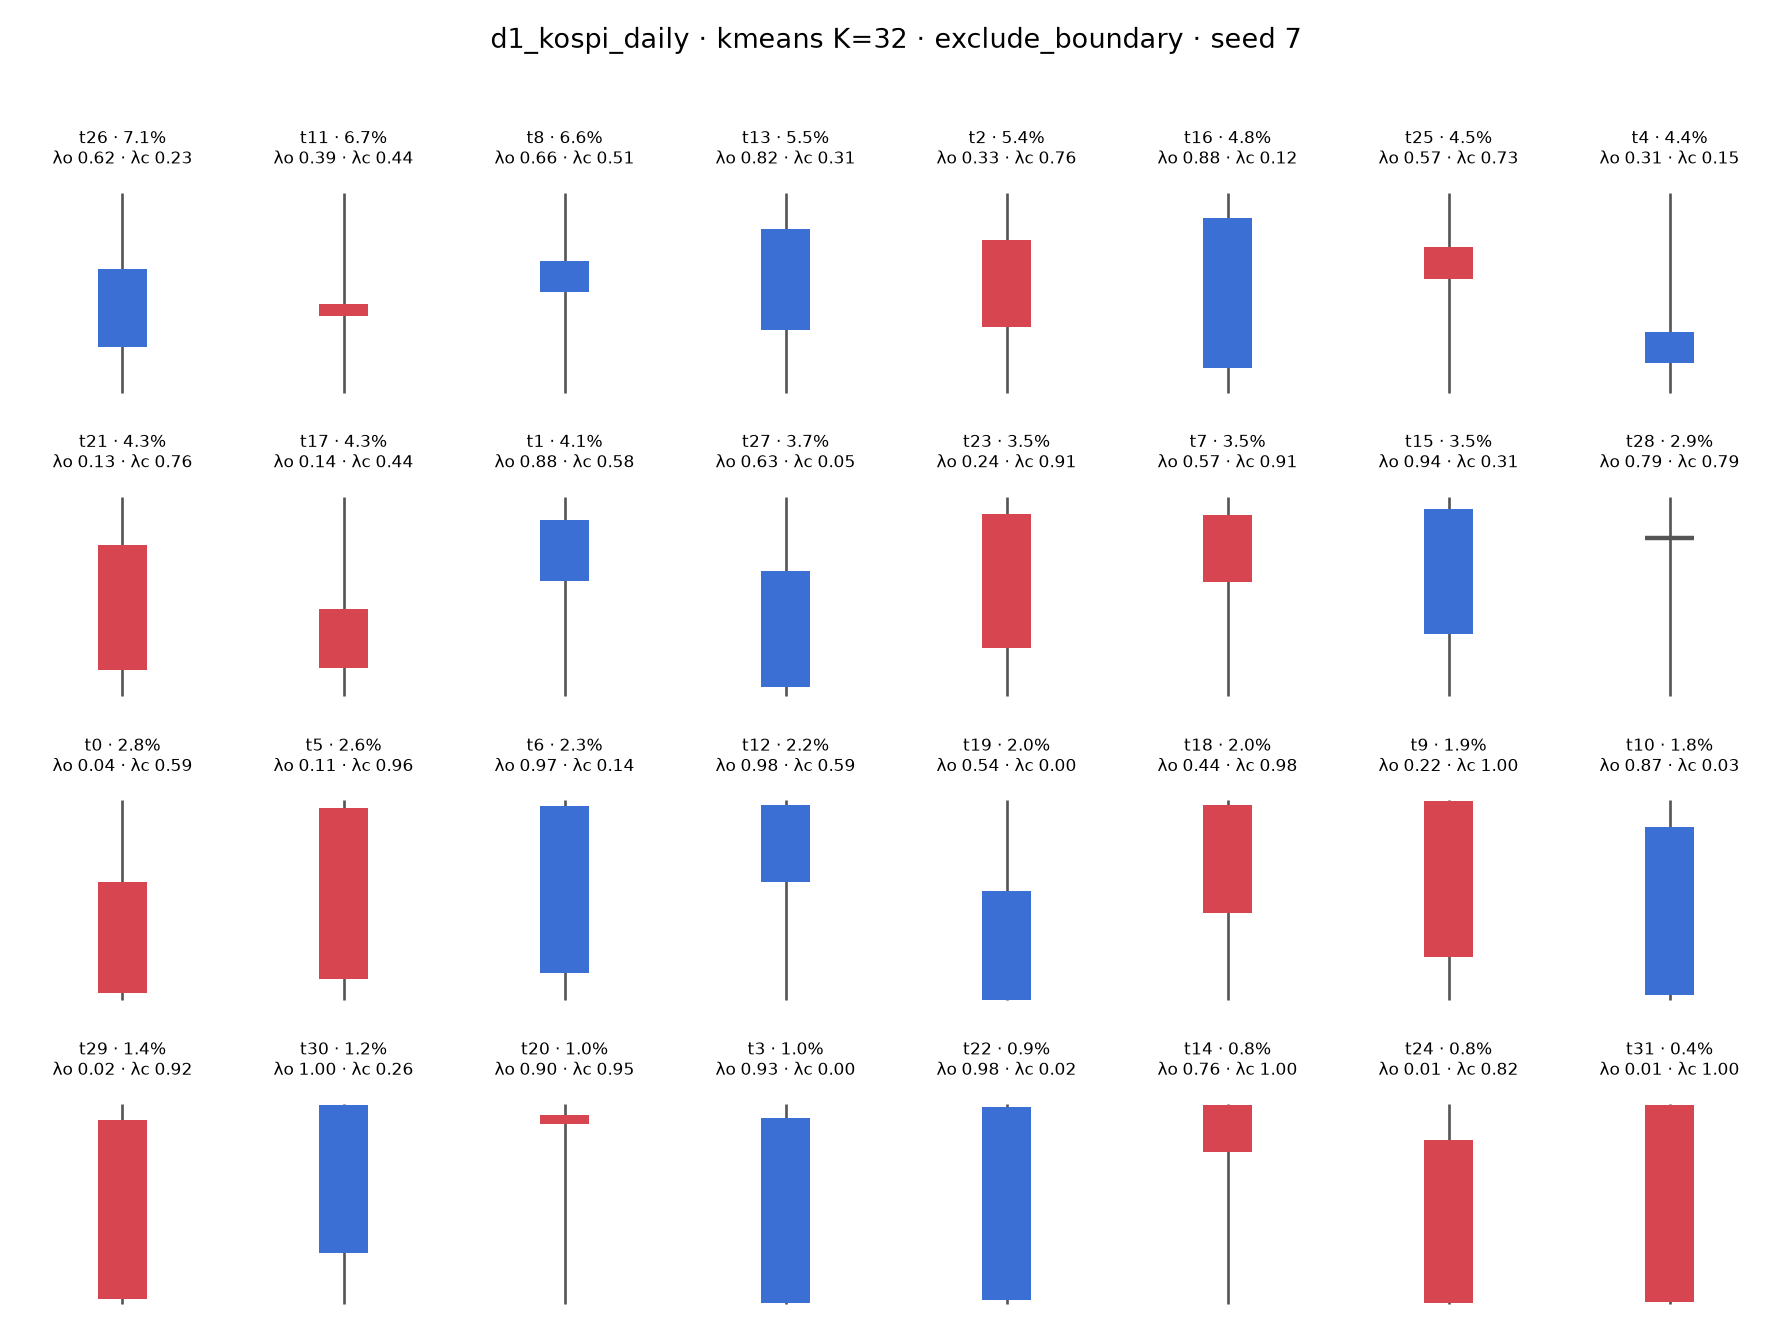

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_1m/cfg-e03165b4/run-20260706-150241_seed-7/figures/token-shapes__d1_kospi_1m__kmeans__k32-include_boundary__seed-7.png


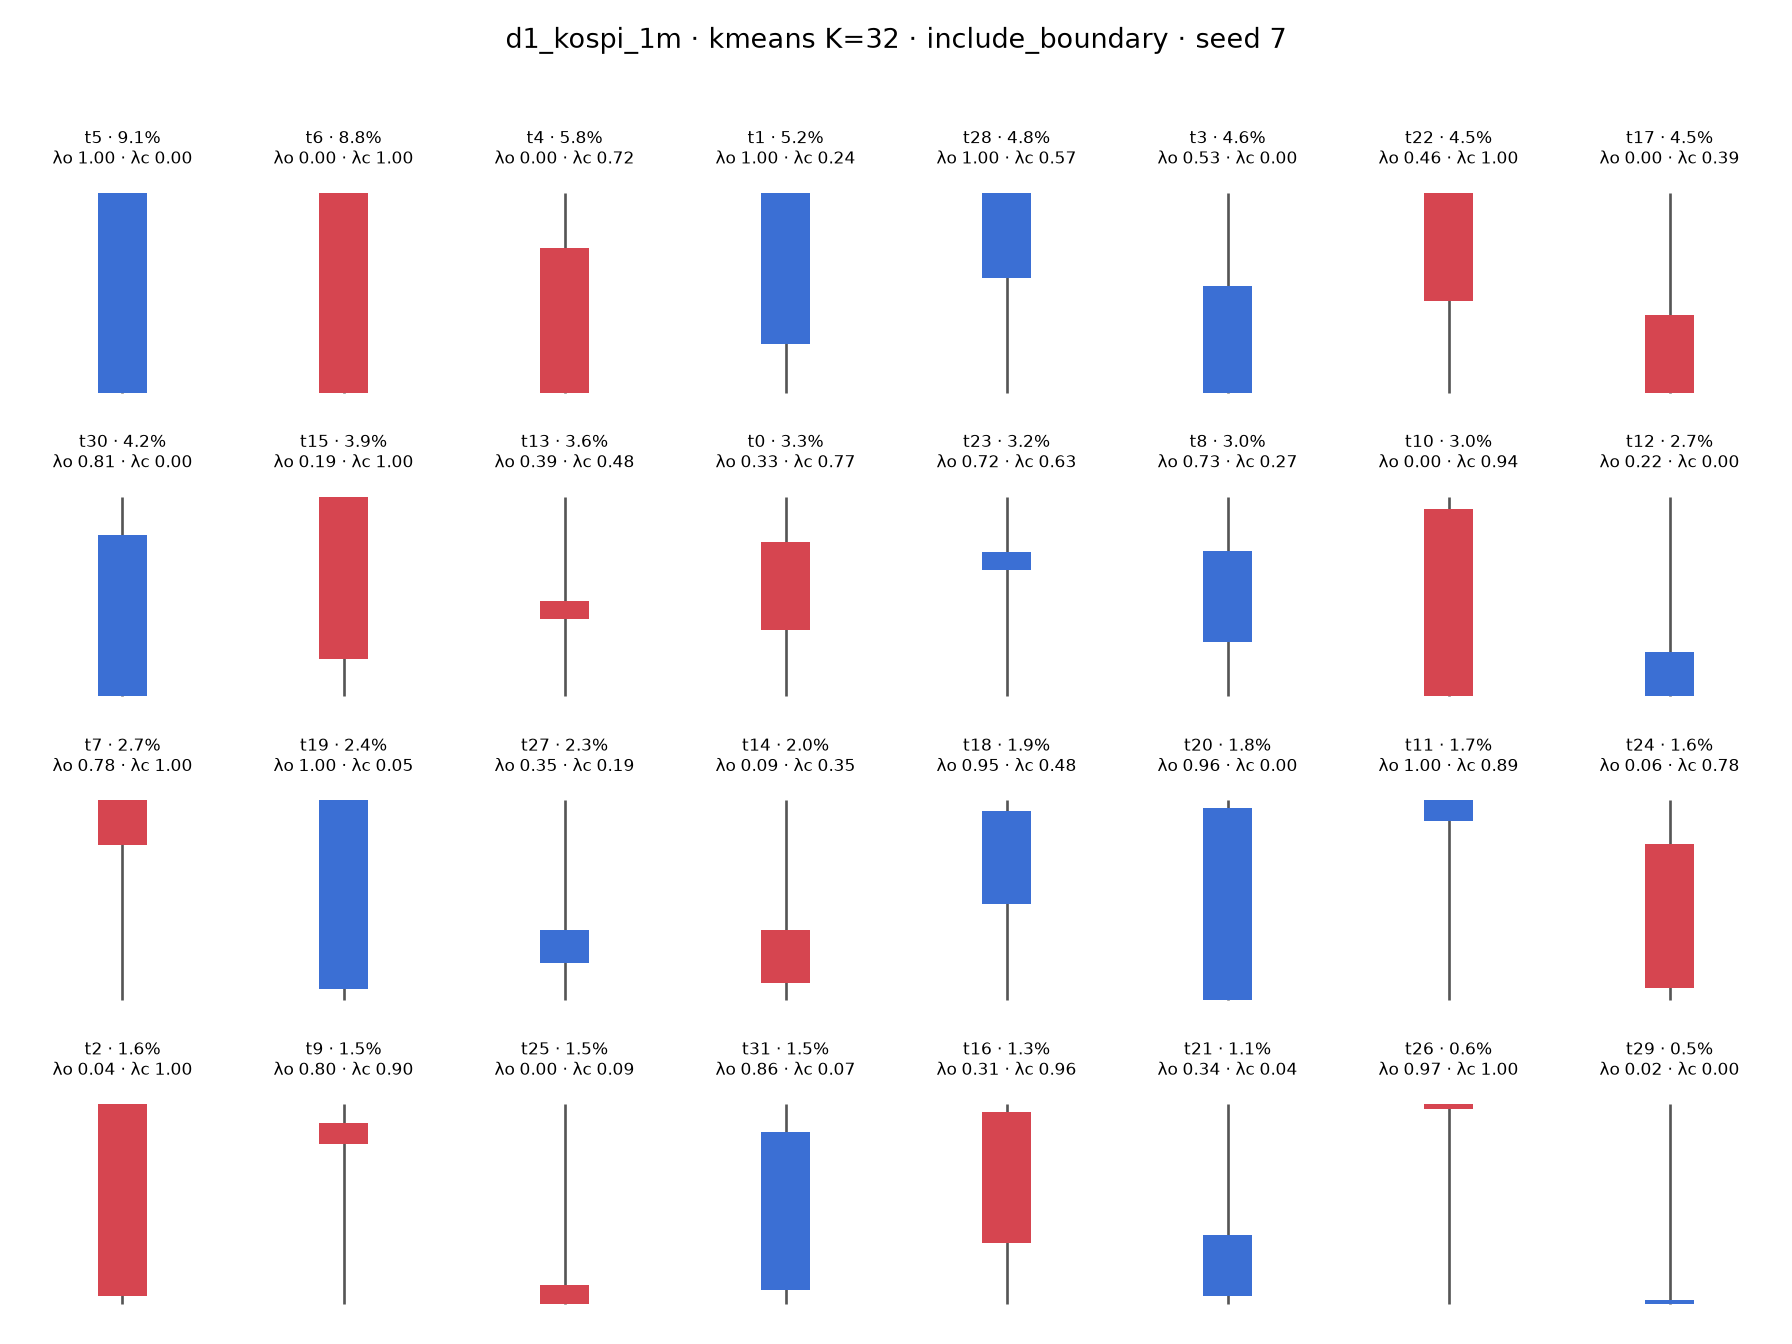

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_1m/cfg-e03165b4/run-20260706-150241_seed-7/figures/token-shapes__d1_kospi_1m__kmeans__k32-exclude_boundary__seed-7.png


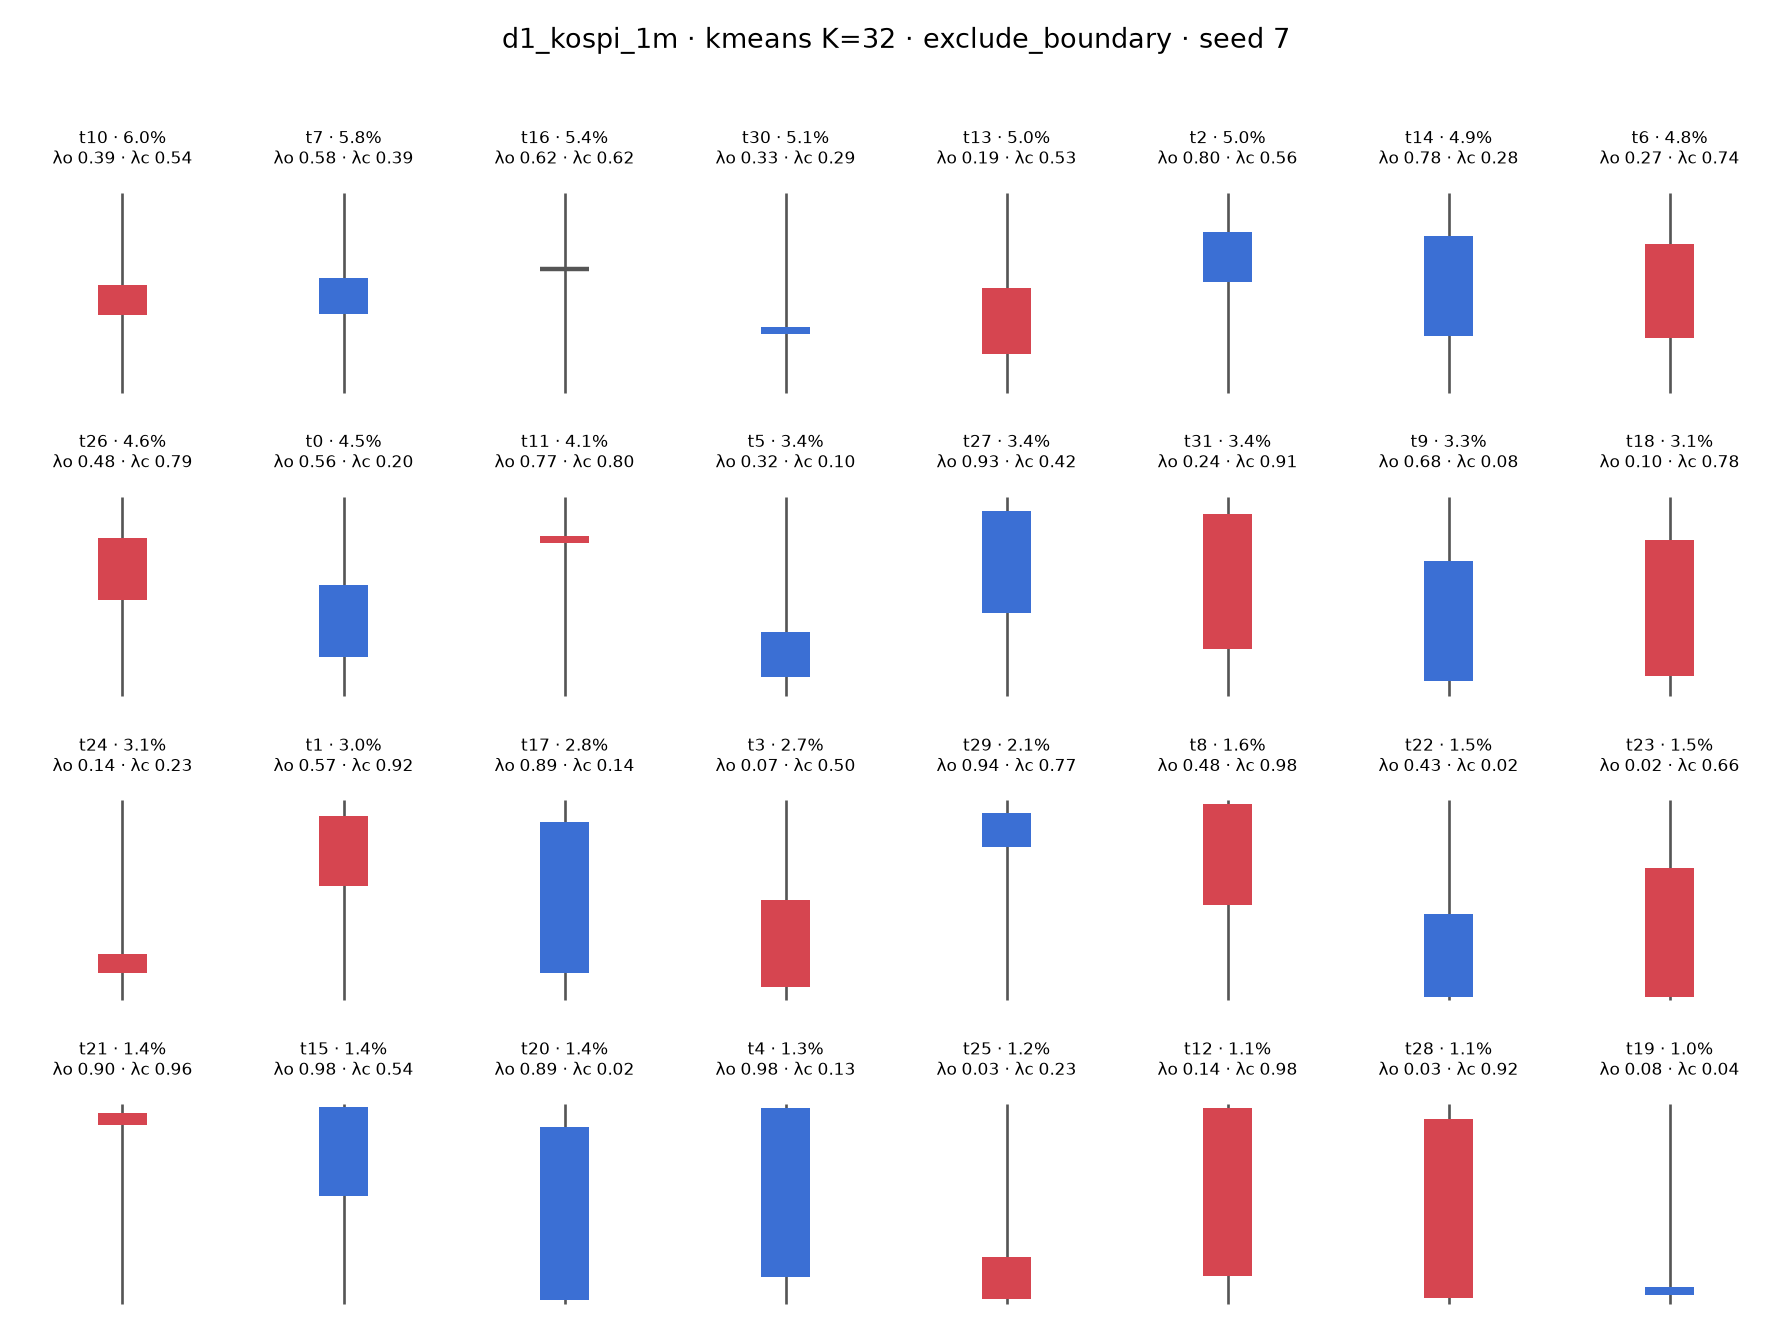

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kosdaq_daily/cfg-e0bd2eb7/run-20260706-150303_seed-7/figures/token-shapes__d1_kosdaq_daily__kmeans__k32-include_boundary__seed-7.png


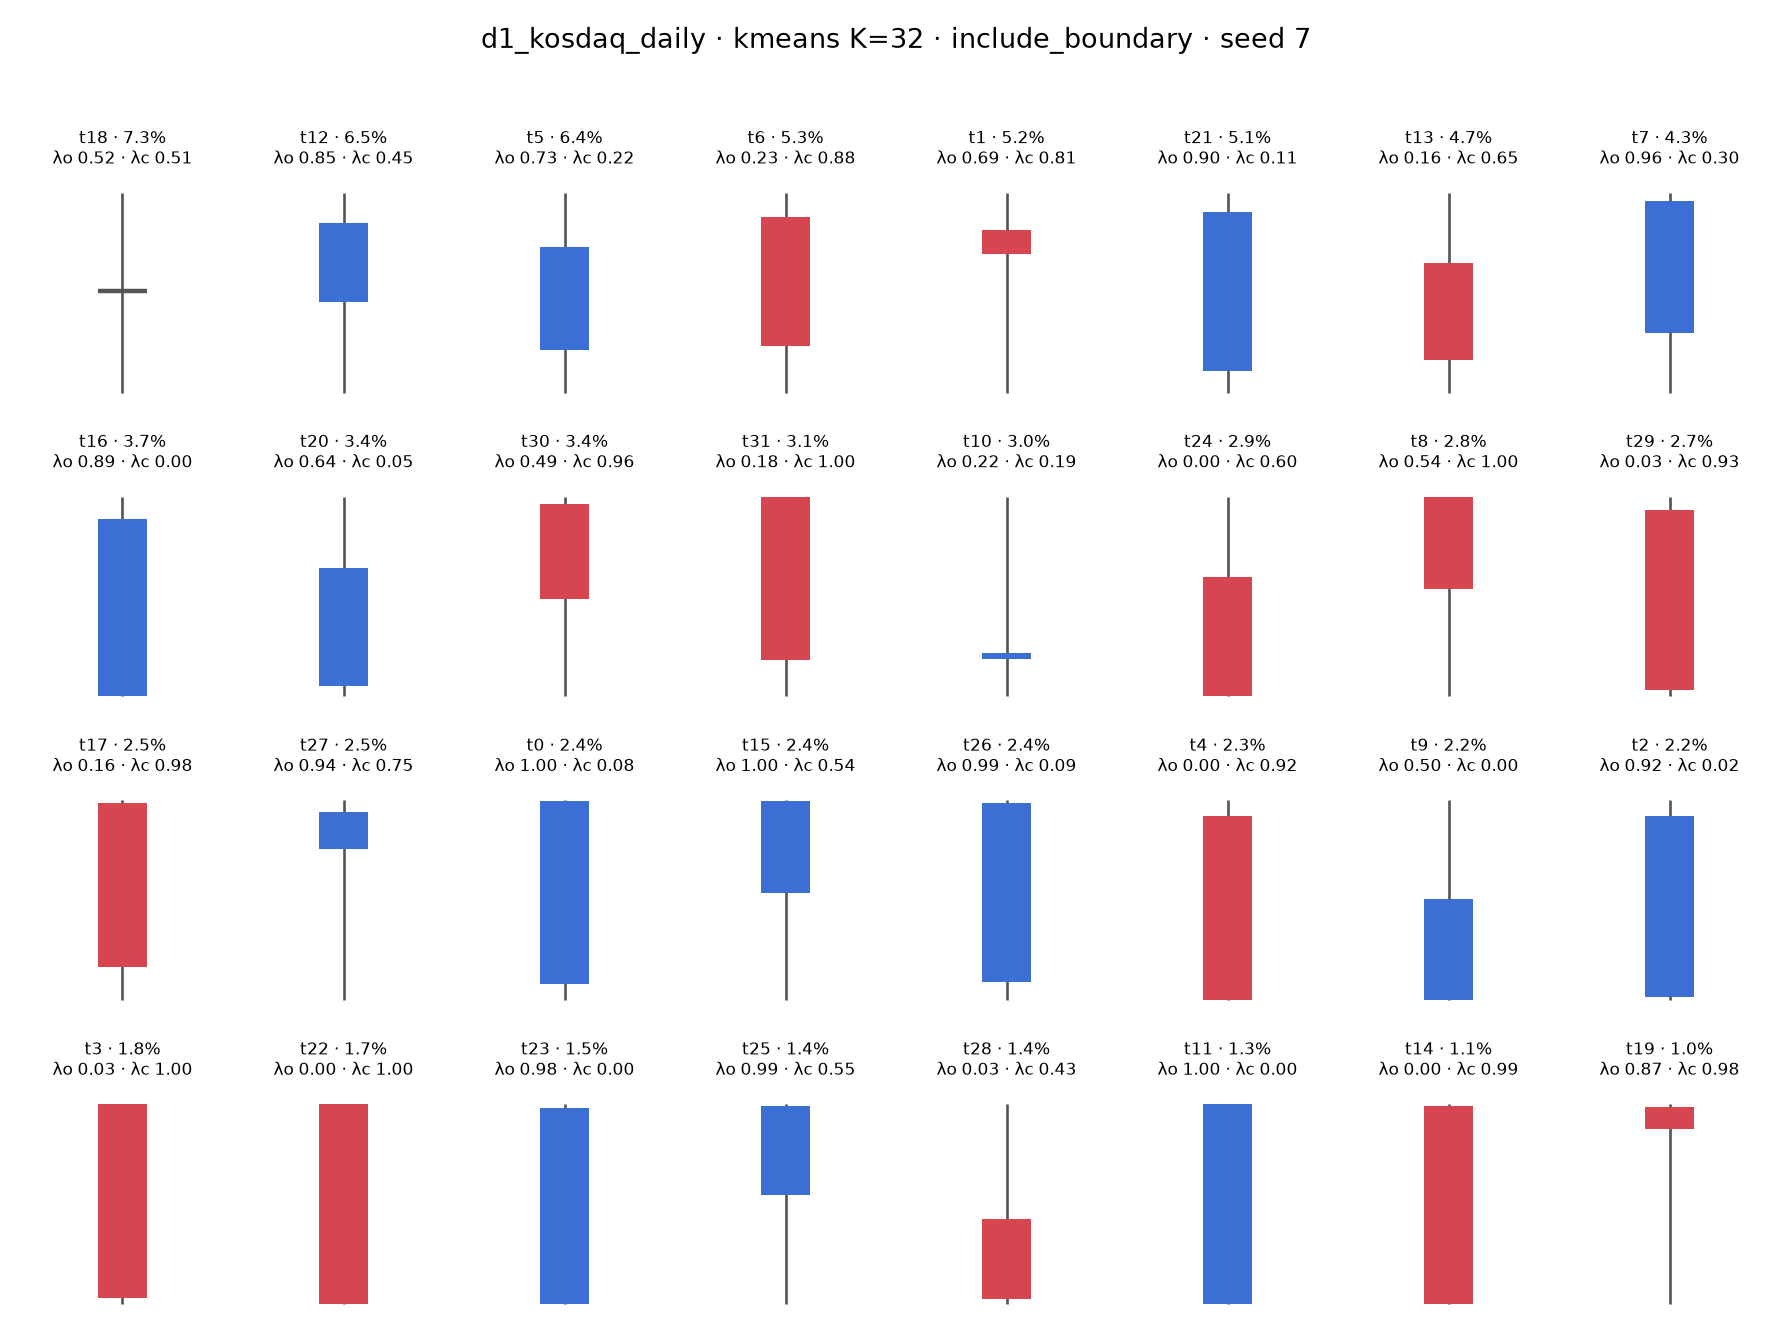

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kosdaq_daily/cfg-e0bd2eb7/run-20260706-150303_seed-7/figures/token-shapes__d1_kosdaq_daily__kmeans__k32-exclude_boundary__seed-7.png


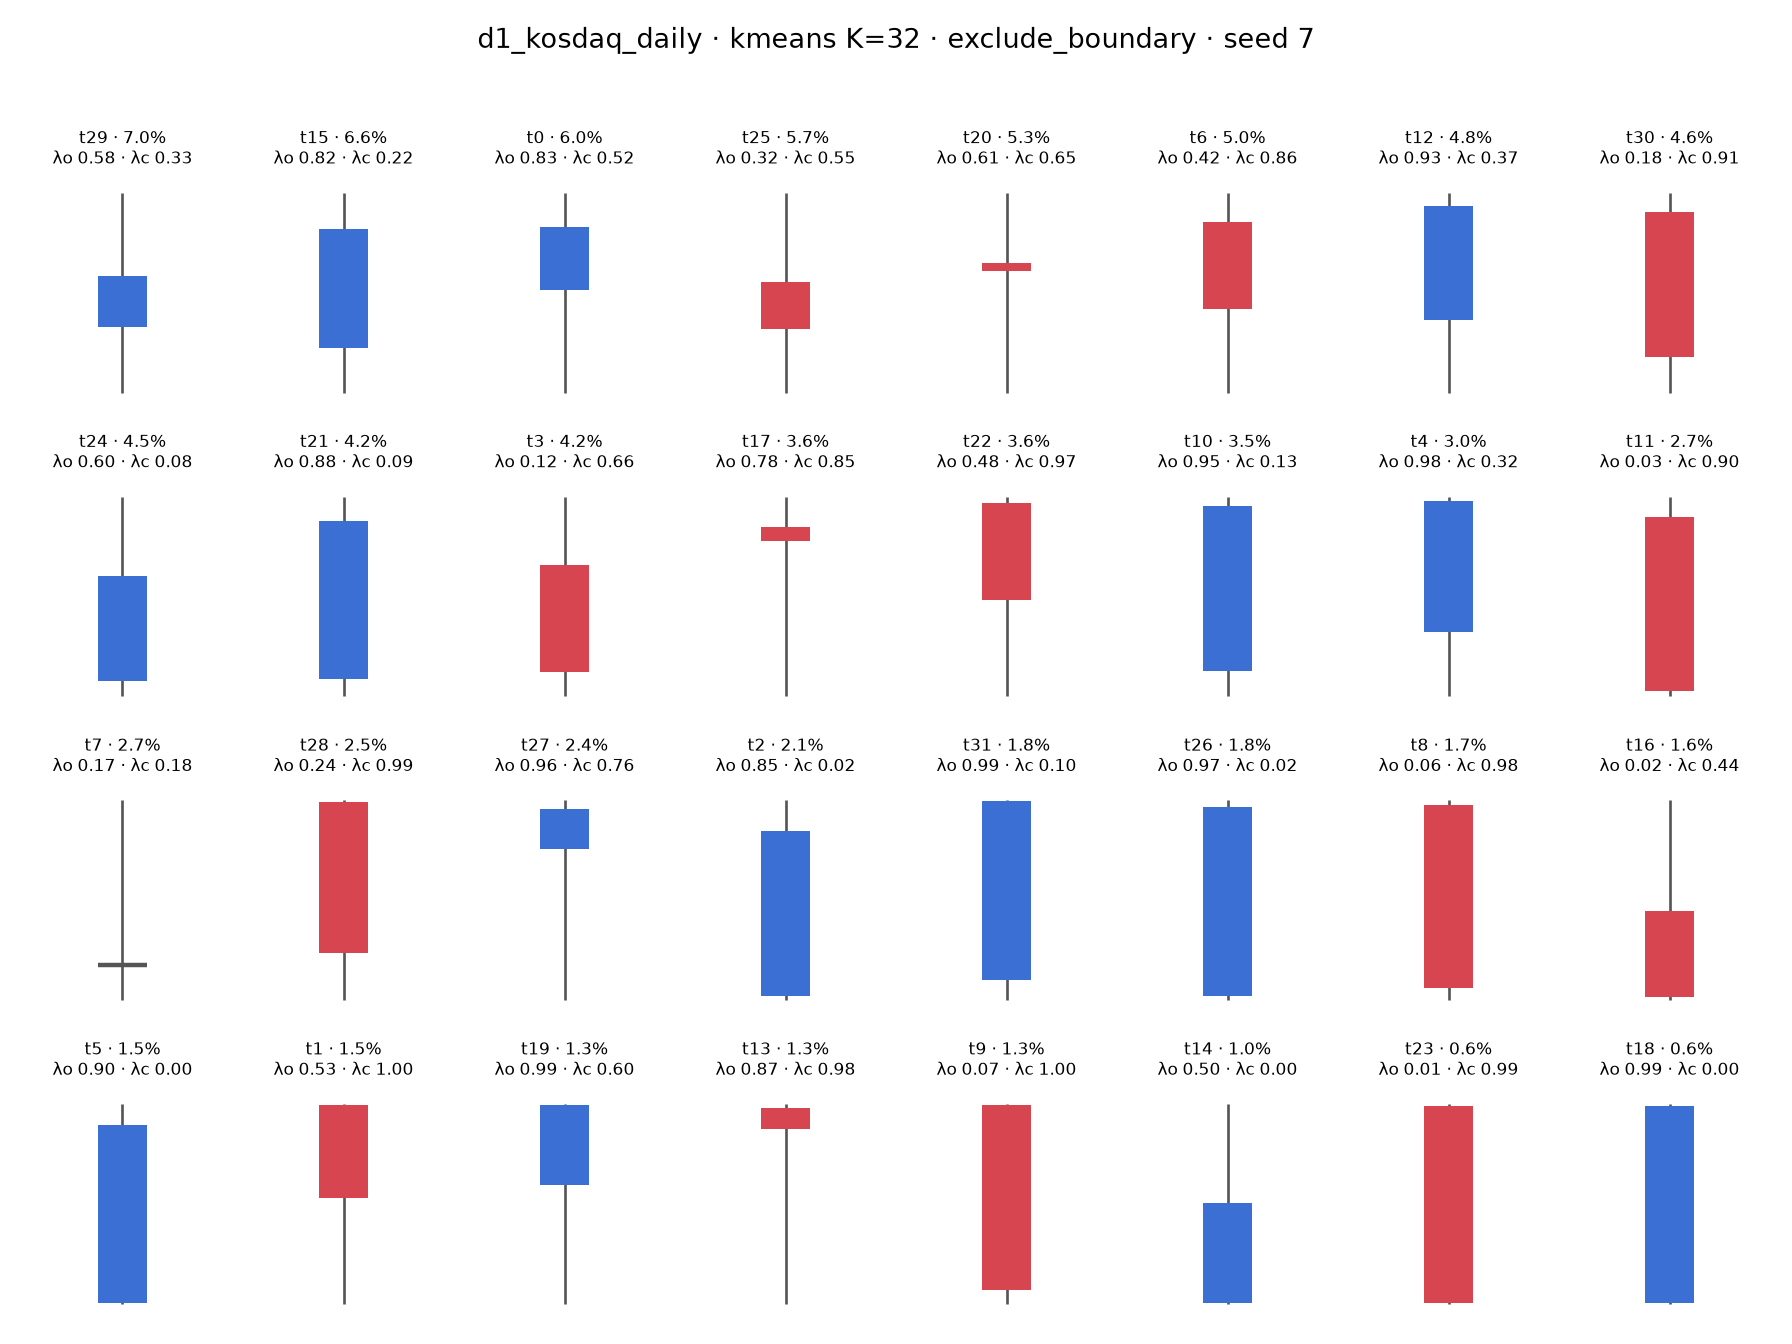

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kosdaq_1m/cfg-7fff2966/run-20260706-150309_seed-7/figures/token-shapes__d1_kosdaq_1m__kmeans__k32-include_boundary__seed-7.png


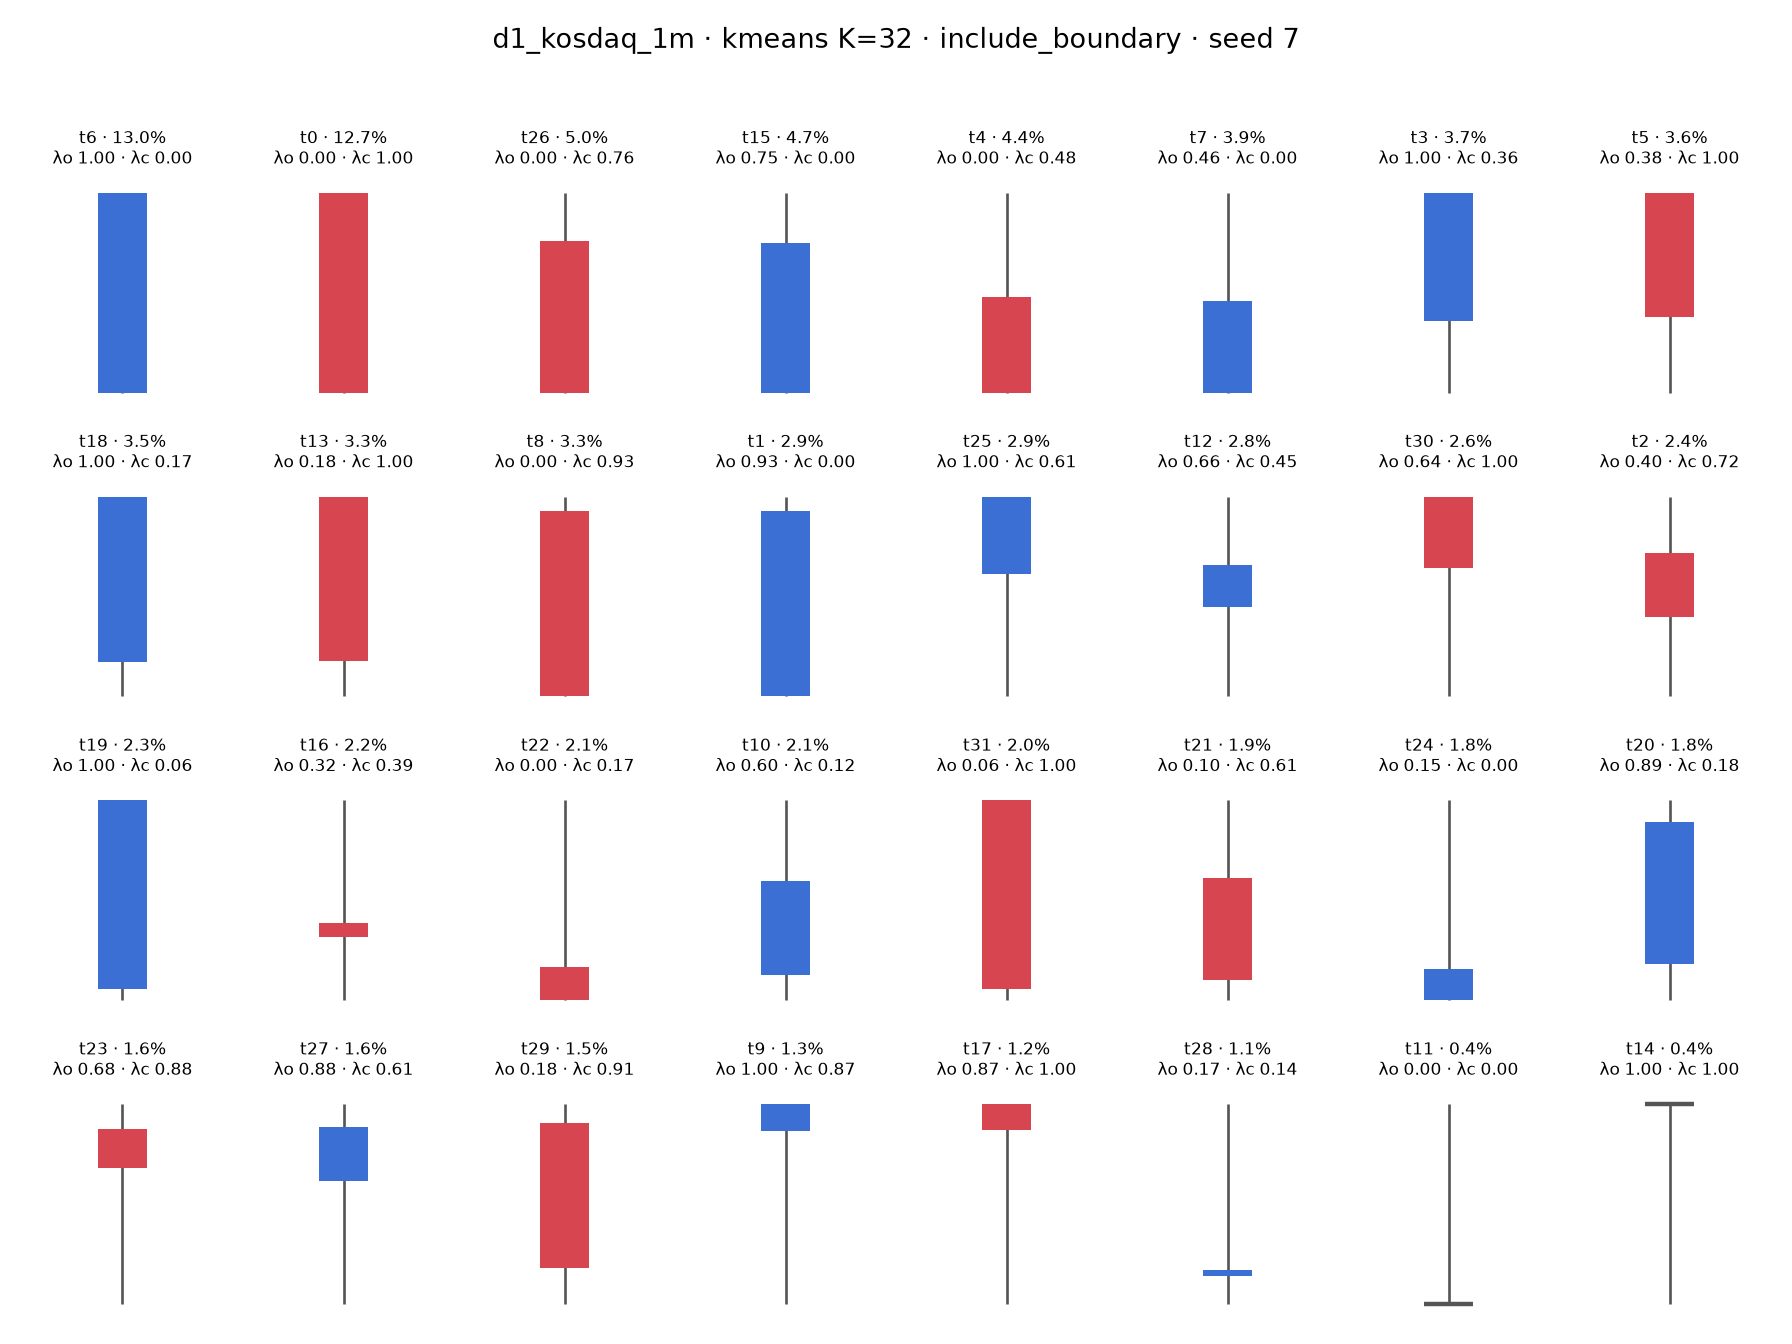

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kosdaq_1m/cfg-7fff2966/run-20260706-150309_seed-7/figures/token-shapes__d1_kosdaq_1m__kmeans__k32-exclude_boundary__seed-7.png


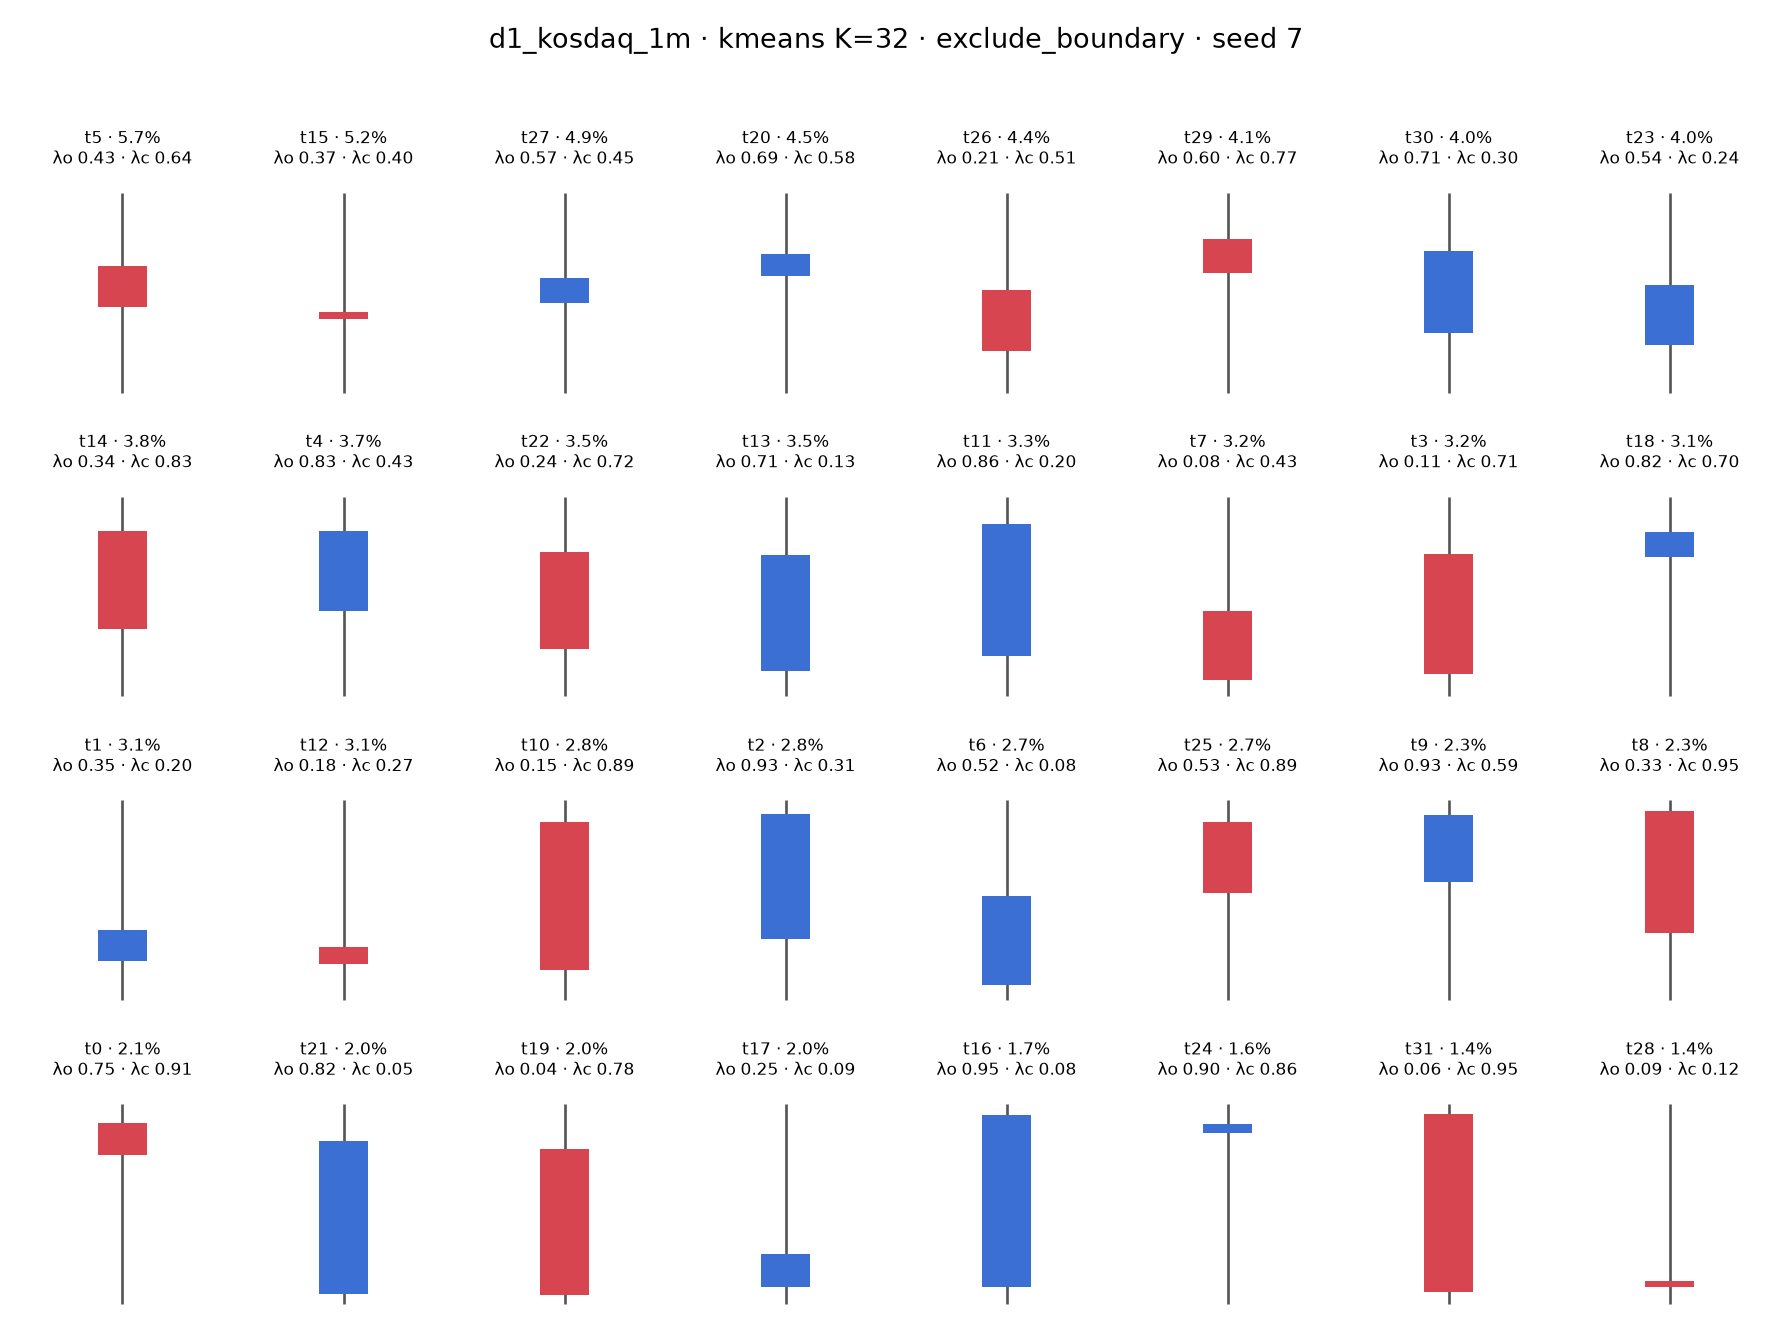

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_nasdaq_daily/cfg-960d7a53/run-20260706-150330_seed-7/figures/token-shapes__d1_nasdaq_daily__kmeans__k32-include_boundary__seed-7.png


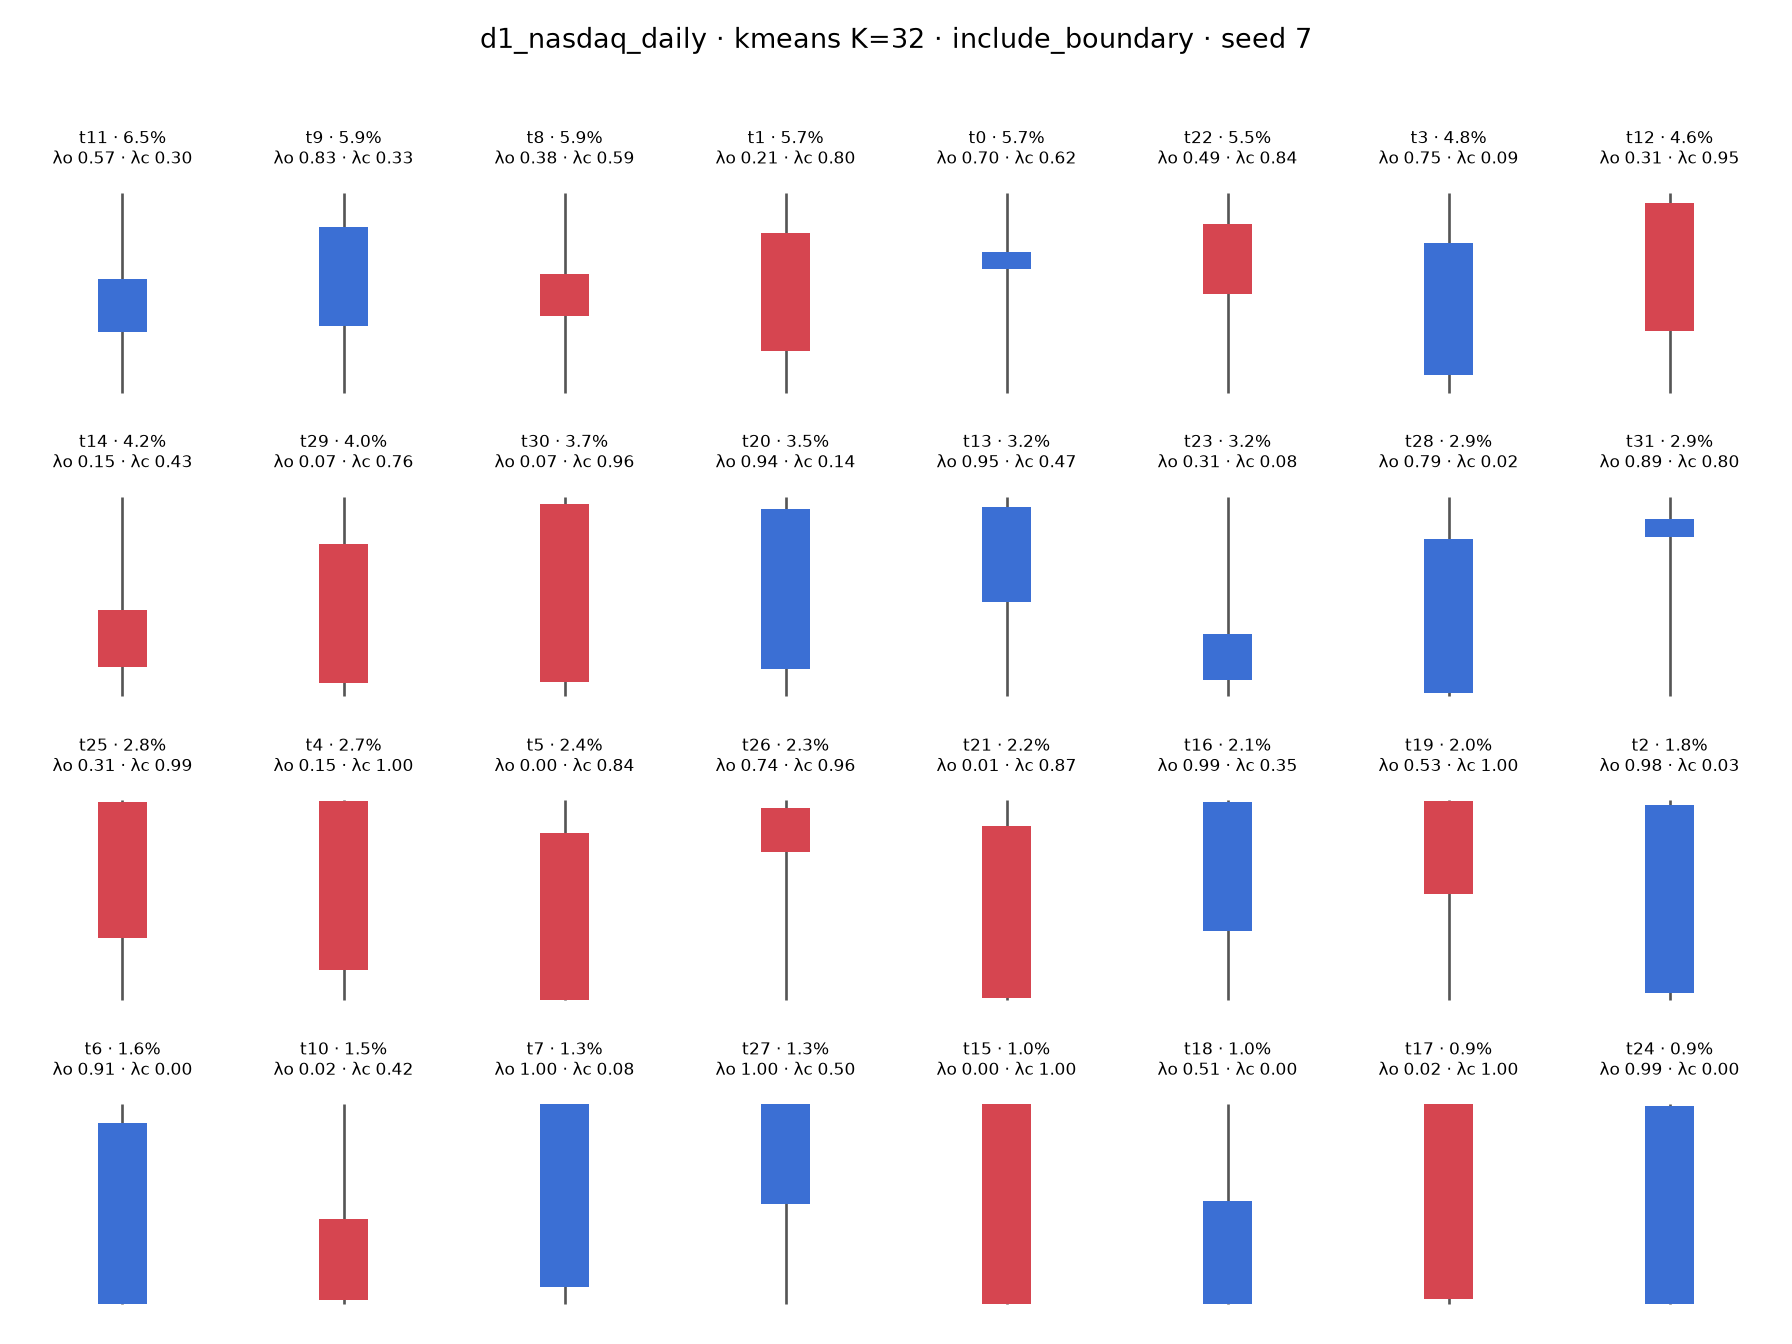

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_nasdaq_daily/cfg-960d7a53/run-20260706-150330_seed-7/figures/token-shapes__d1_nasdaq_daily__kmeans__k32-exclude_boundary__seed-7.png


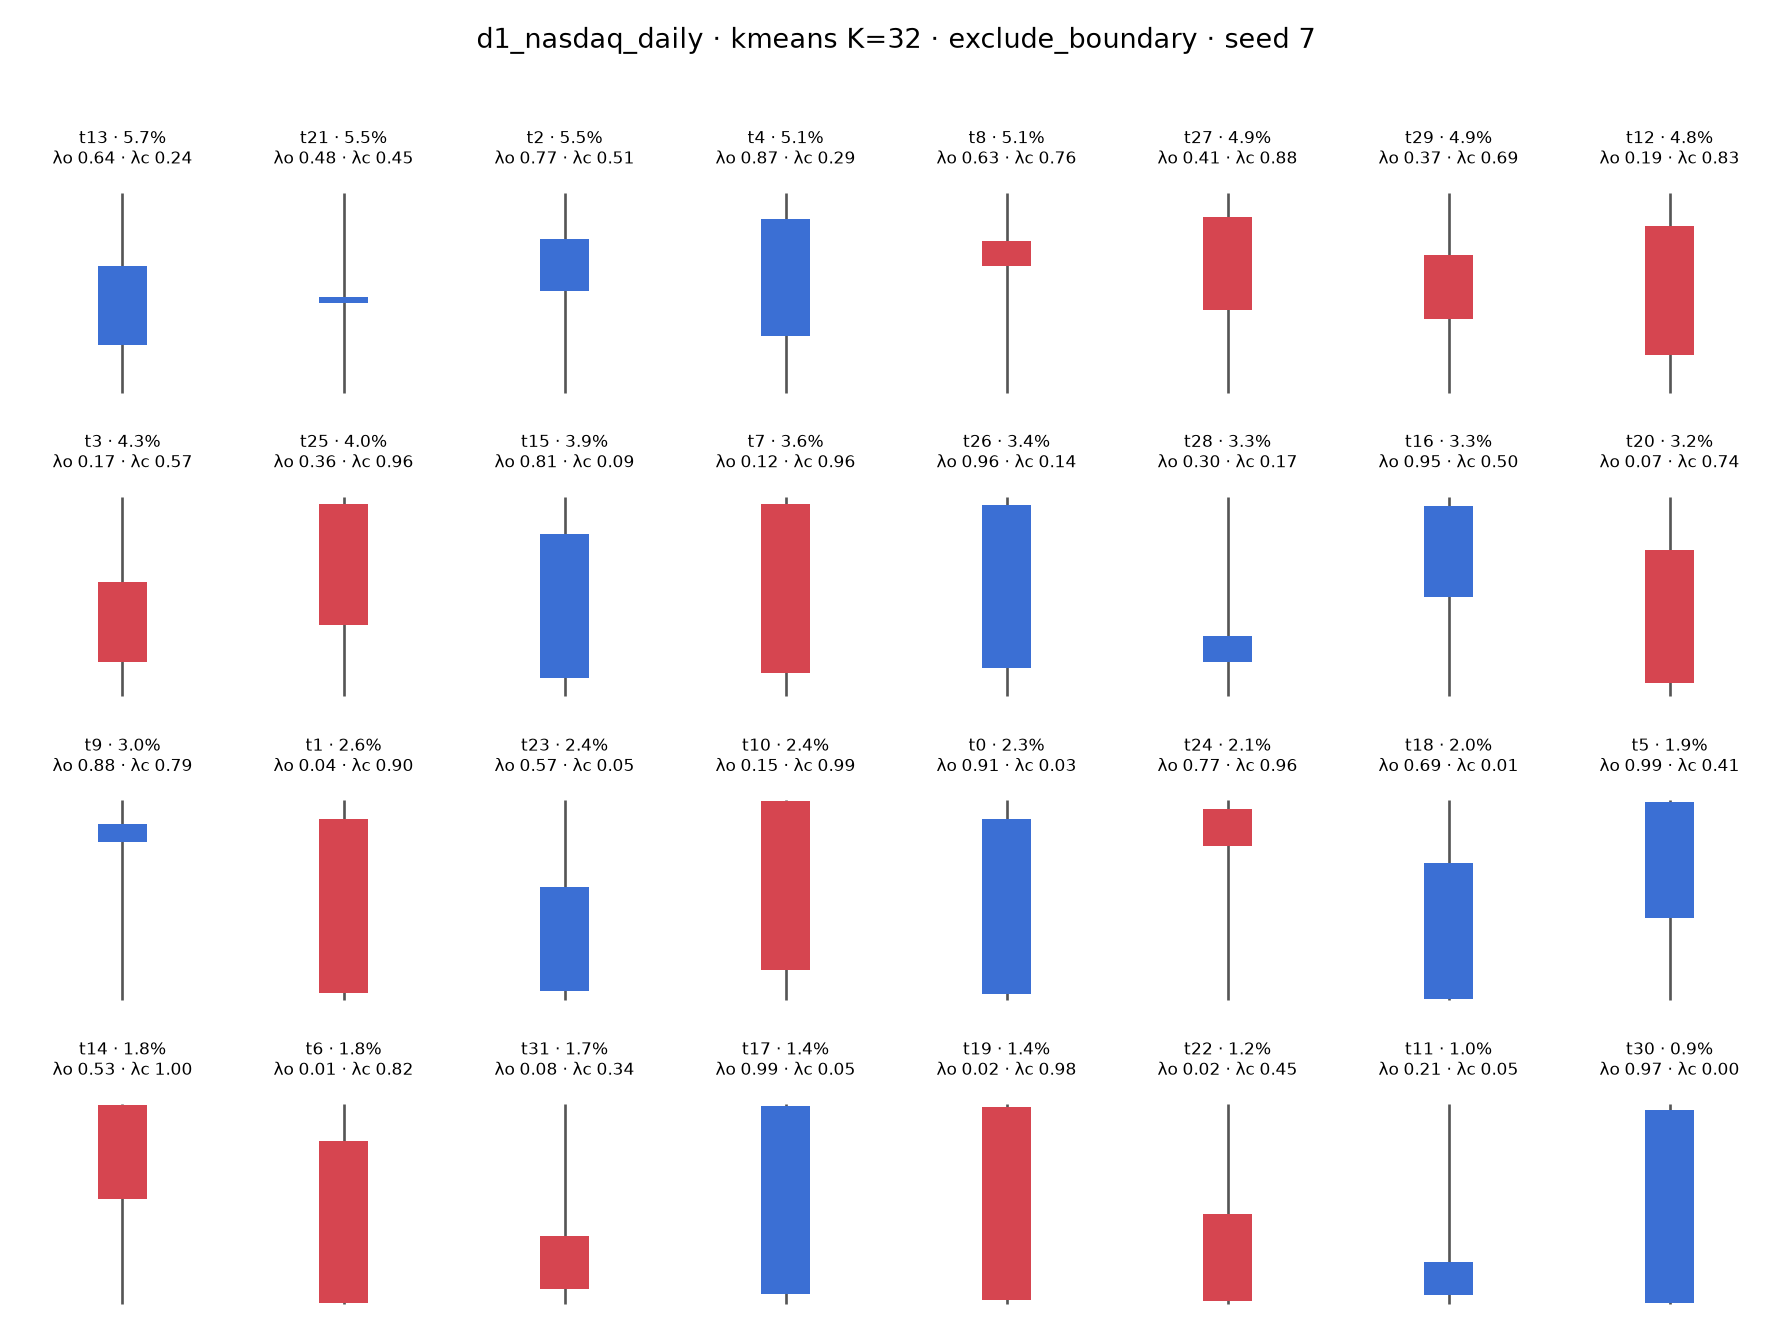

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_spx_daily/cfg-fc473cf1/run-20260706-150336_seed-7/figures/token-shapes__d1_spx_daily__kmeans__k32-include_boundary__seed-7.png


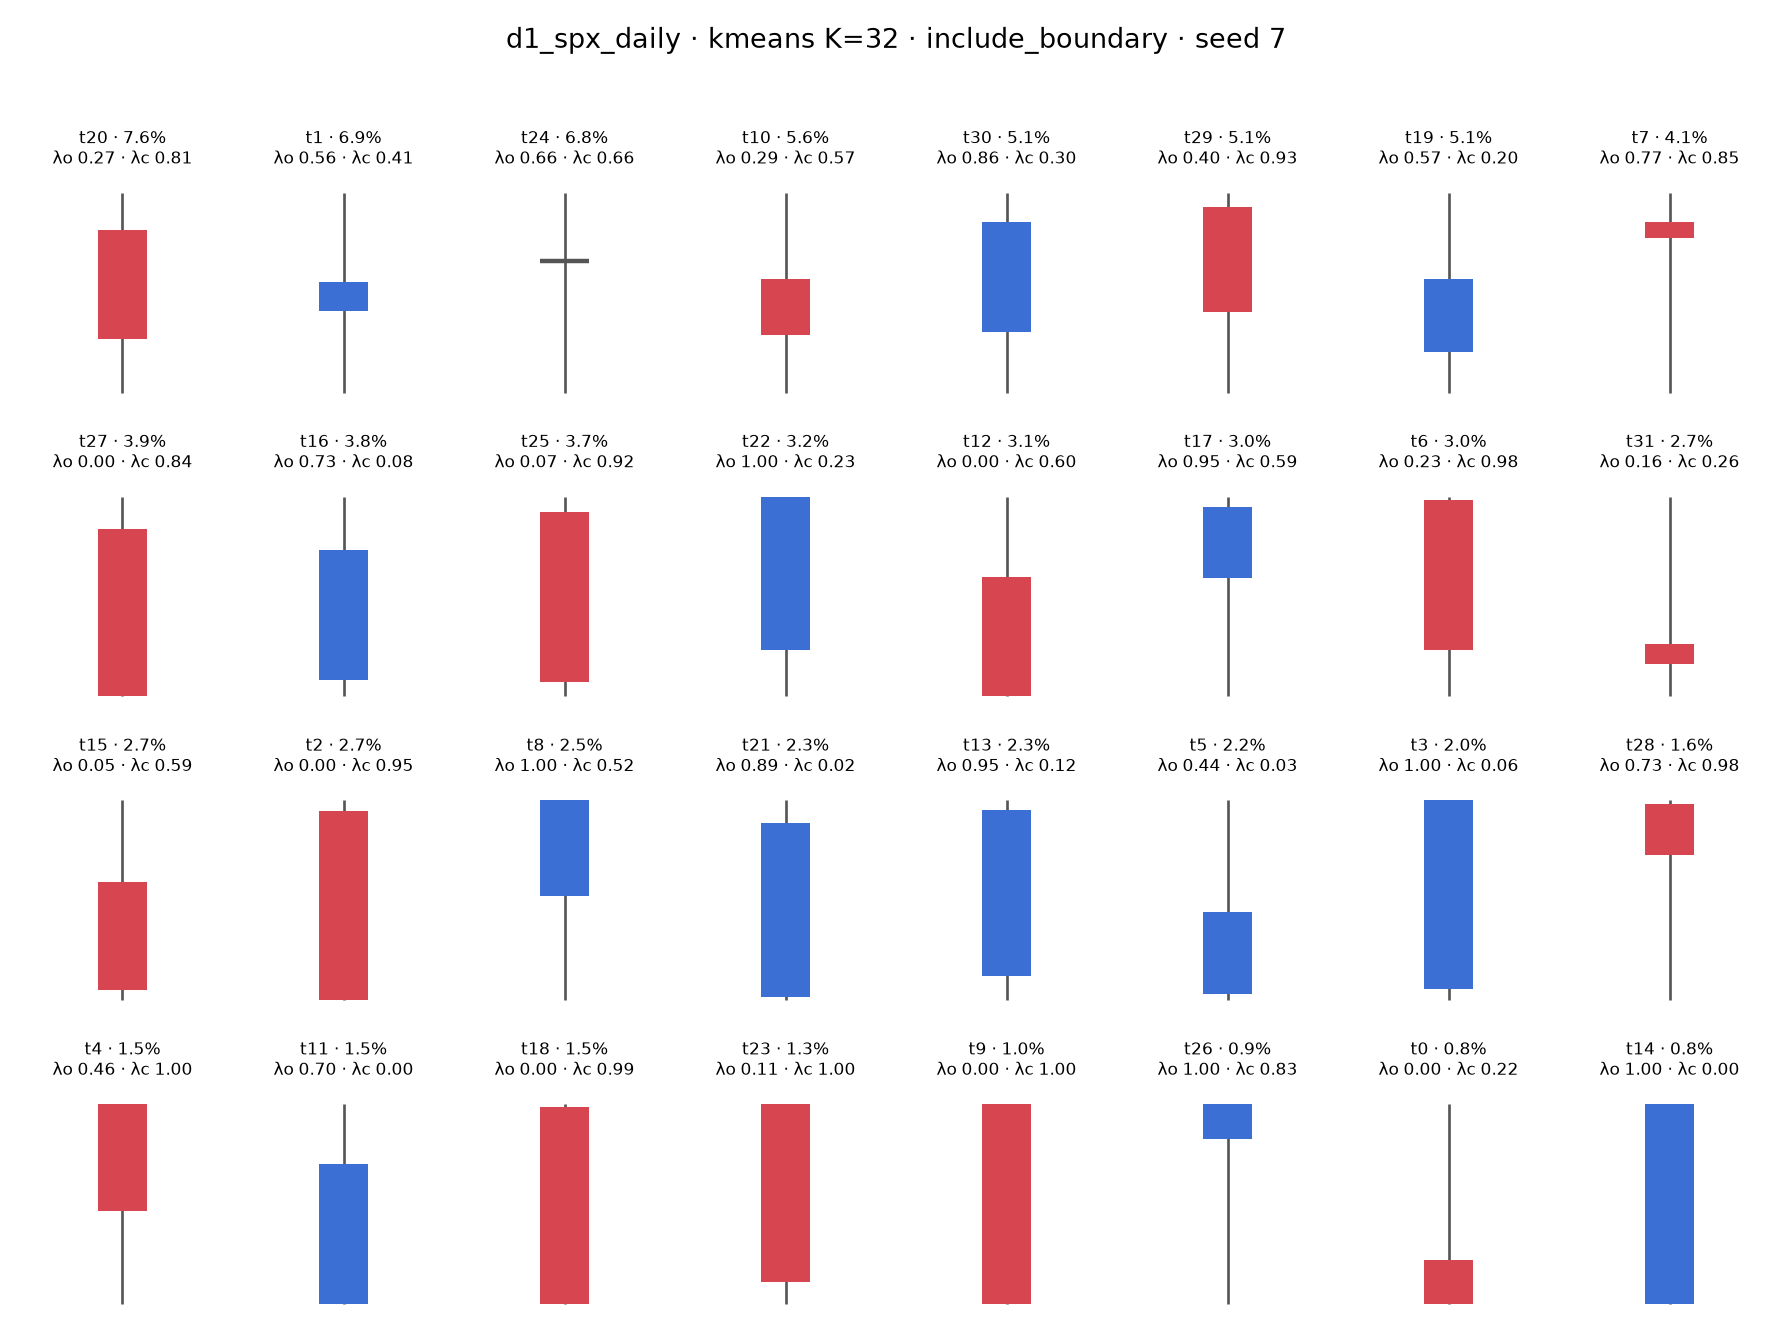

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_spx_daily/cfg-fc473cf1/run-20260706-150336_seed-7/figures/token-shapes__d1_spx_daily__kmeans__k32-exclude_boundary__seed-7.png


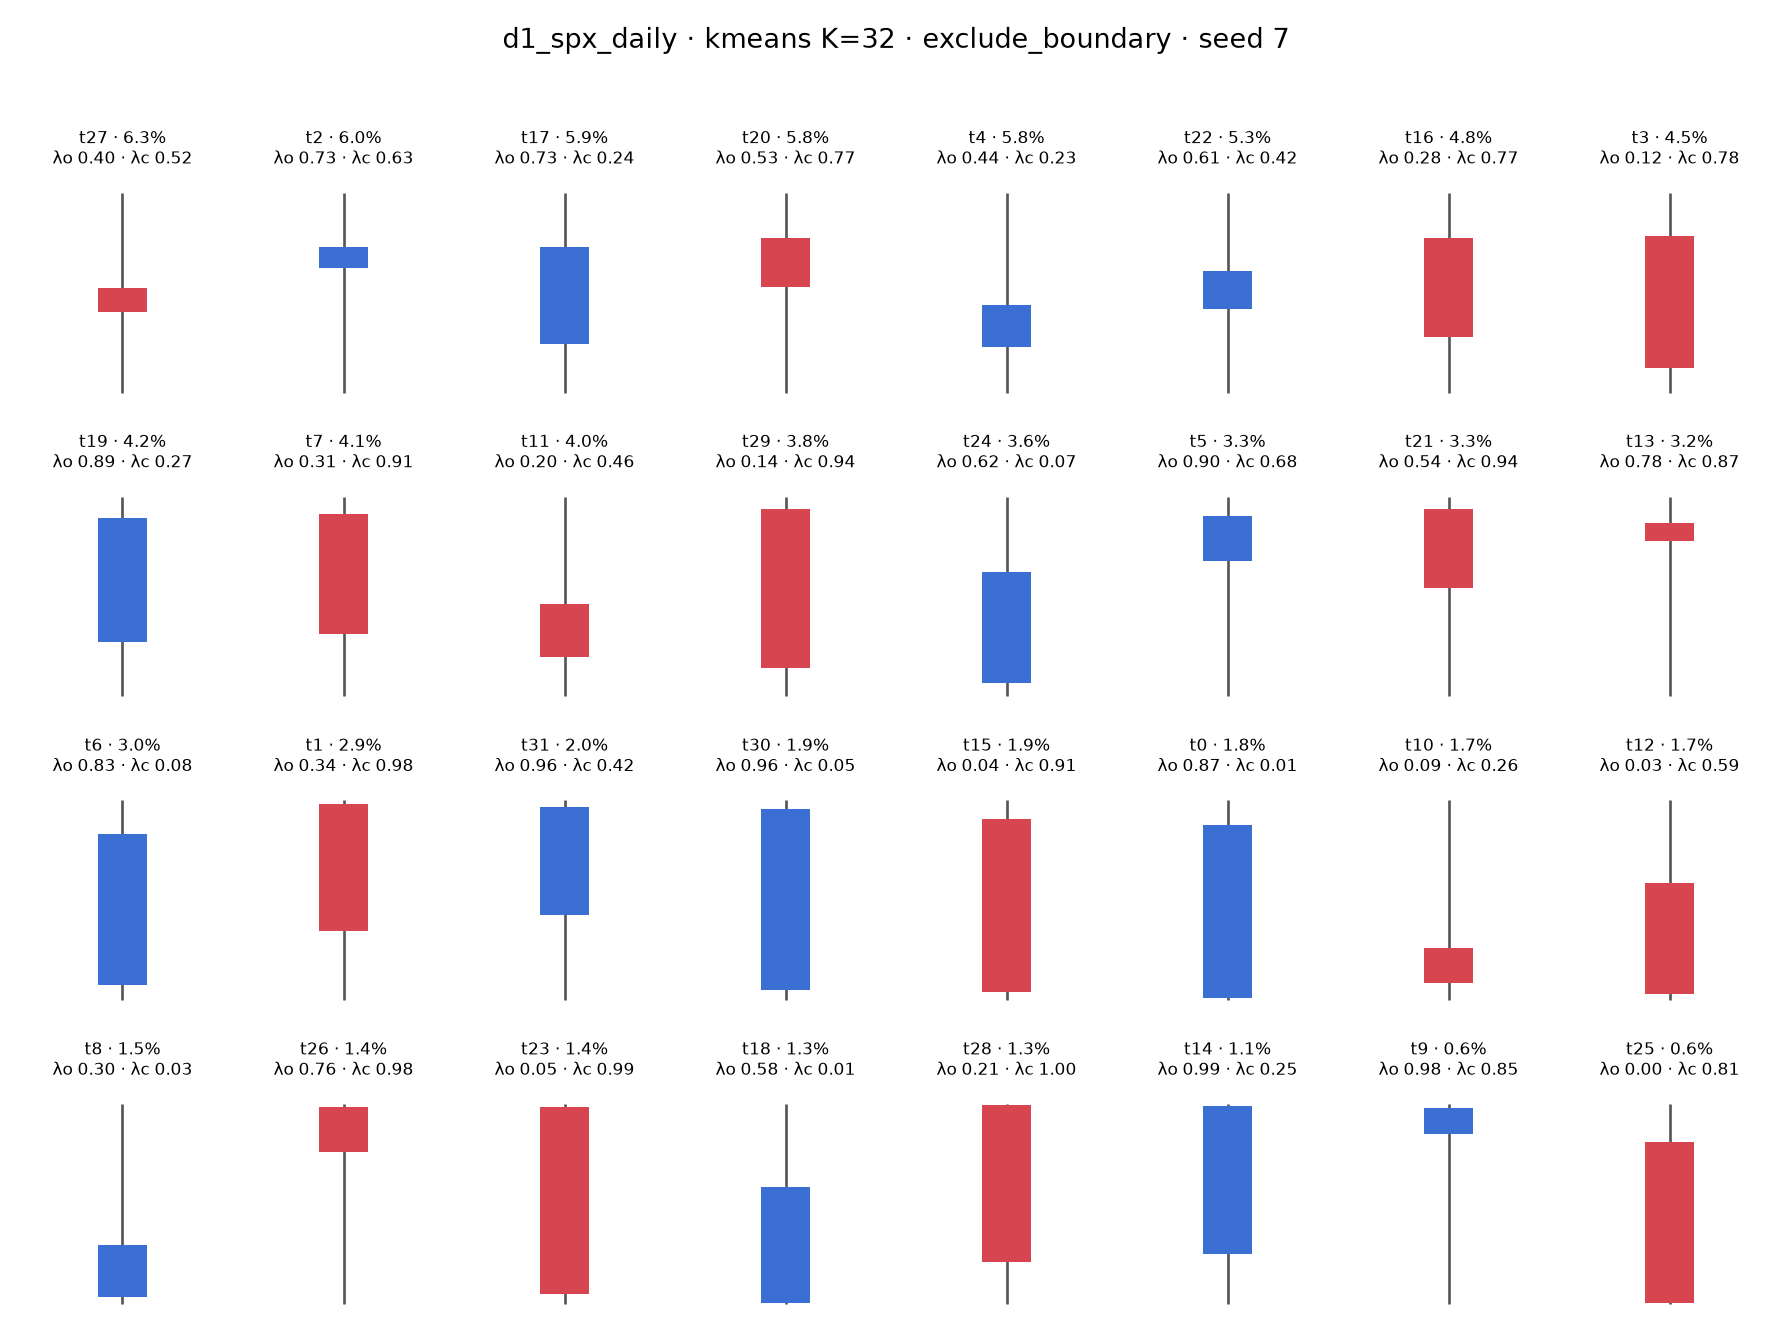

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d2_kr-kospi-kosdaq_daily/cfg-f4c4fcdf/run-20260706-150340_seed-7/figures/token-shapes__d2_kr-kospi-kosdaq_daily__kmeans__k32-include_boundary__seed-7.png


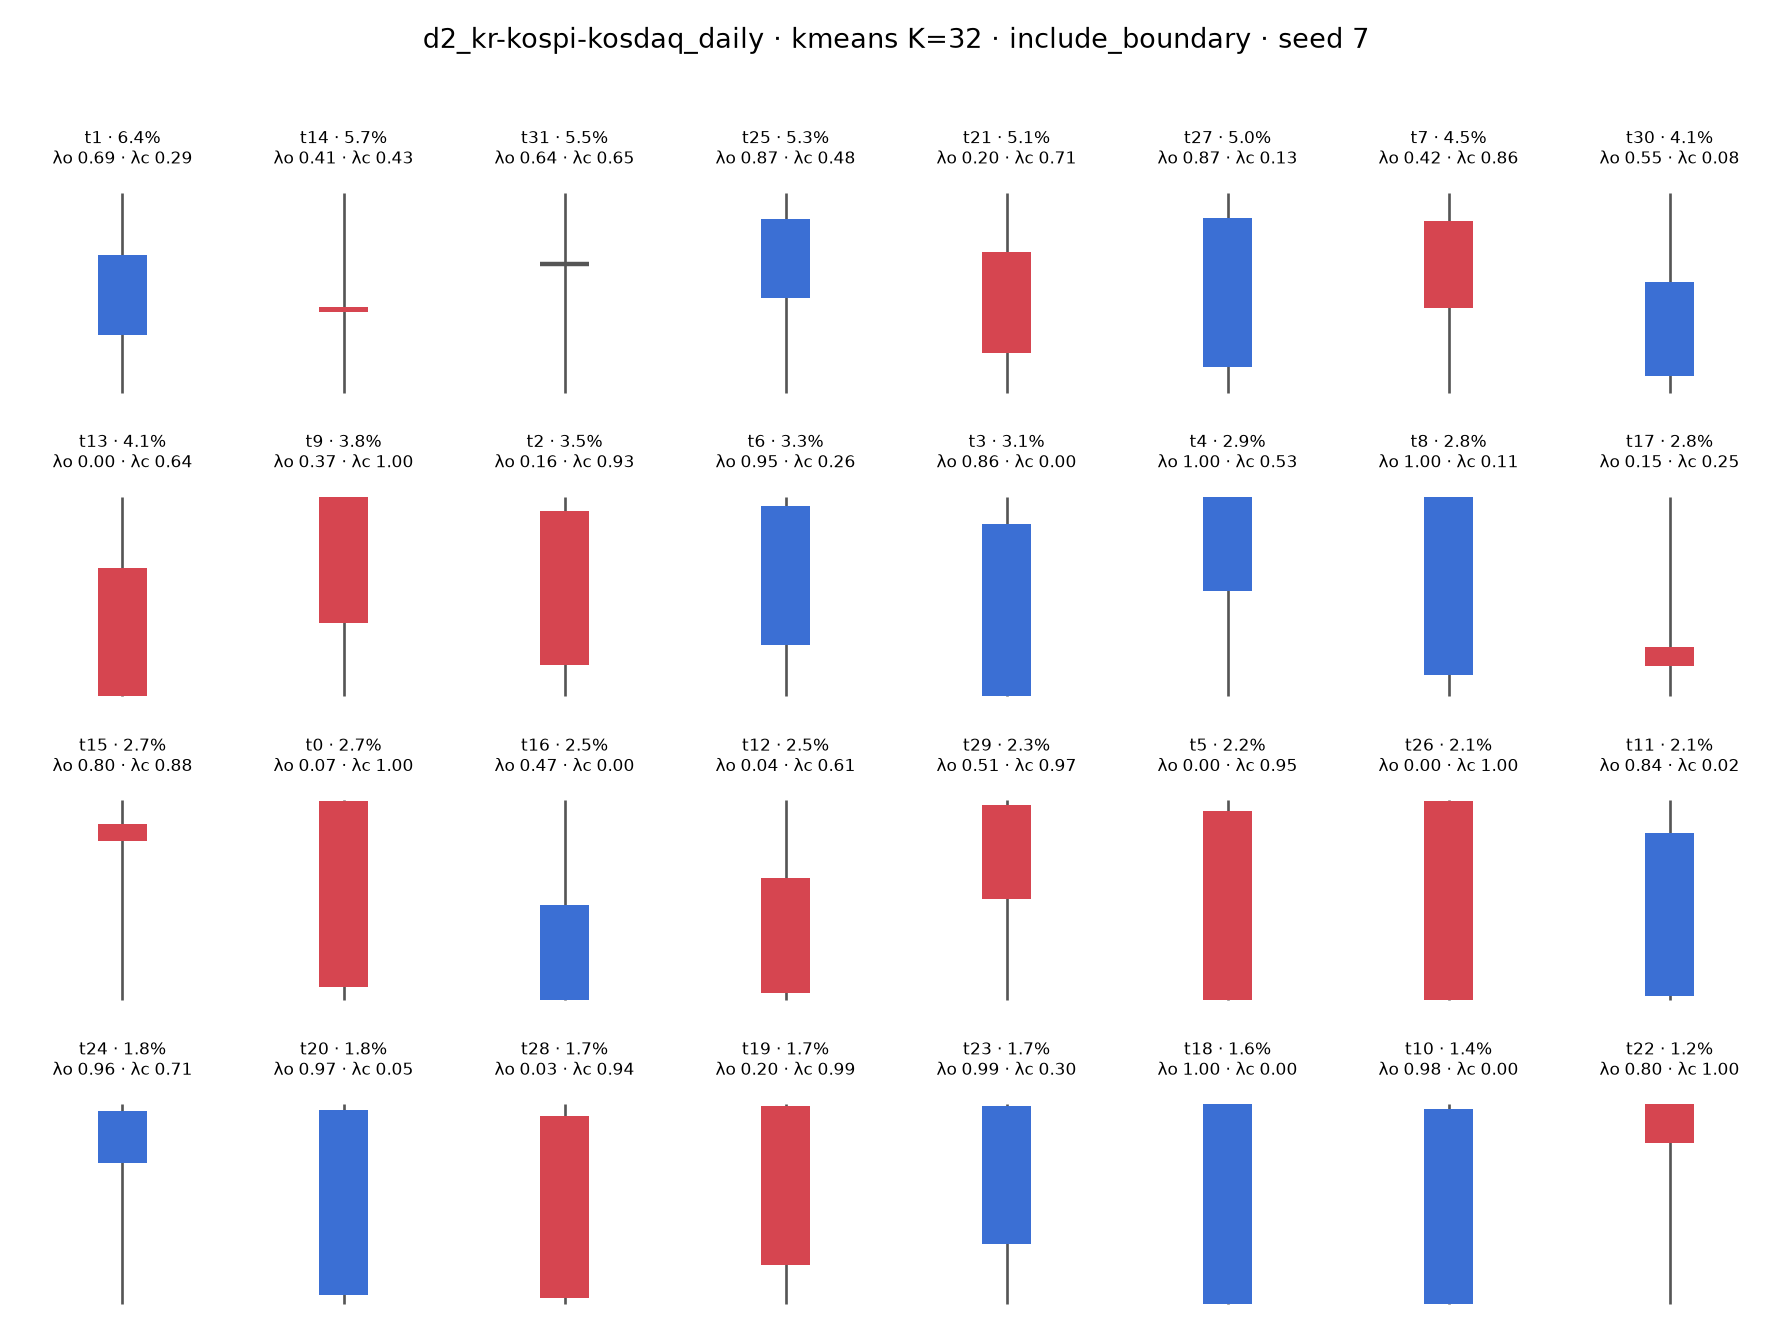

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d2_kr-kospi-kosdaq_daily/cfg-f4c4fcdf/run-20260706-150340_seed-7/figures/token-shapes__d2_kr-kospi-kosdaq_daily__kmeans__k32-exclude_boundary__seed-7.png


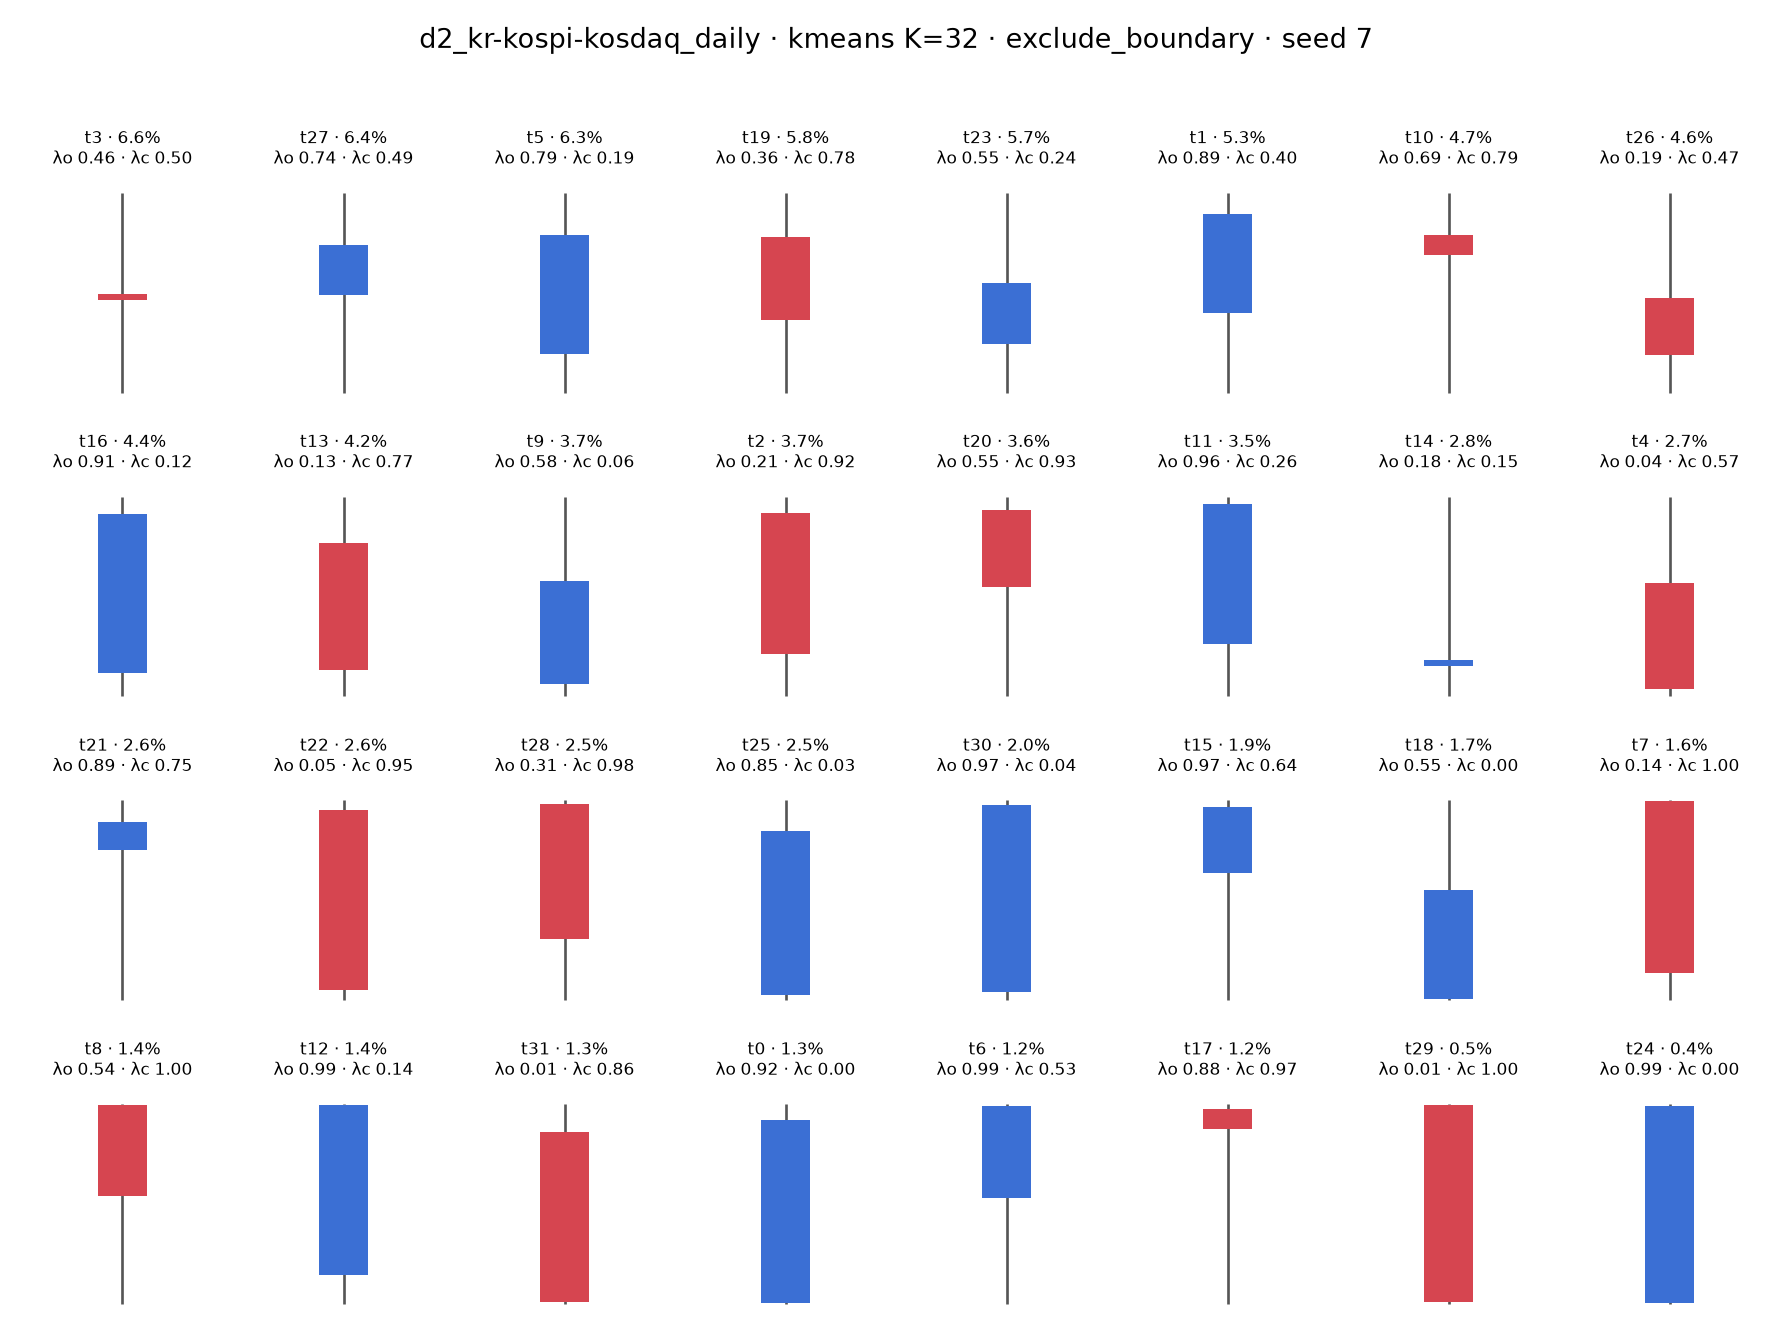

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d2_kr-kospi-kosdaq_1m/cfg-cced087a/run-20260706-150350_seed-7/figures/token-shapes__d2_kr-kospi-kosdaq_1m__kmeans__k32-include_boundary__seed-7.png


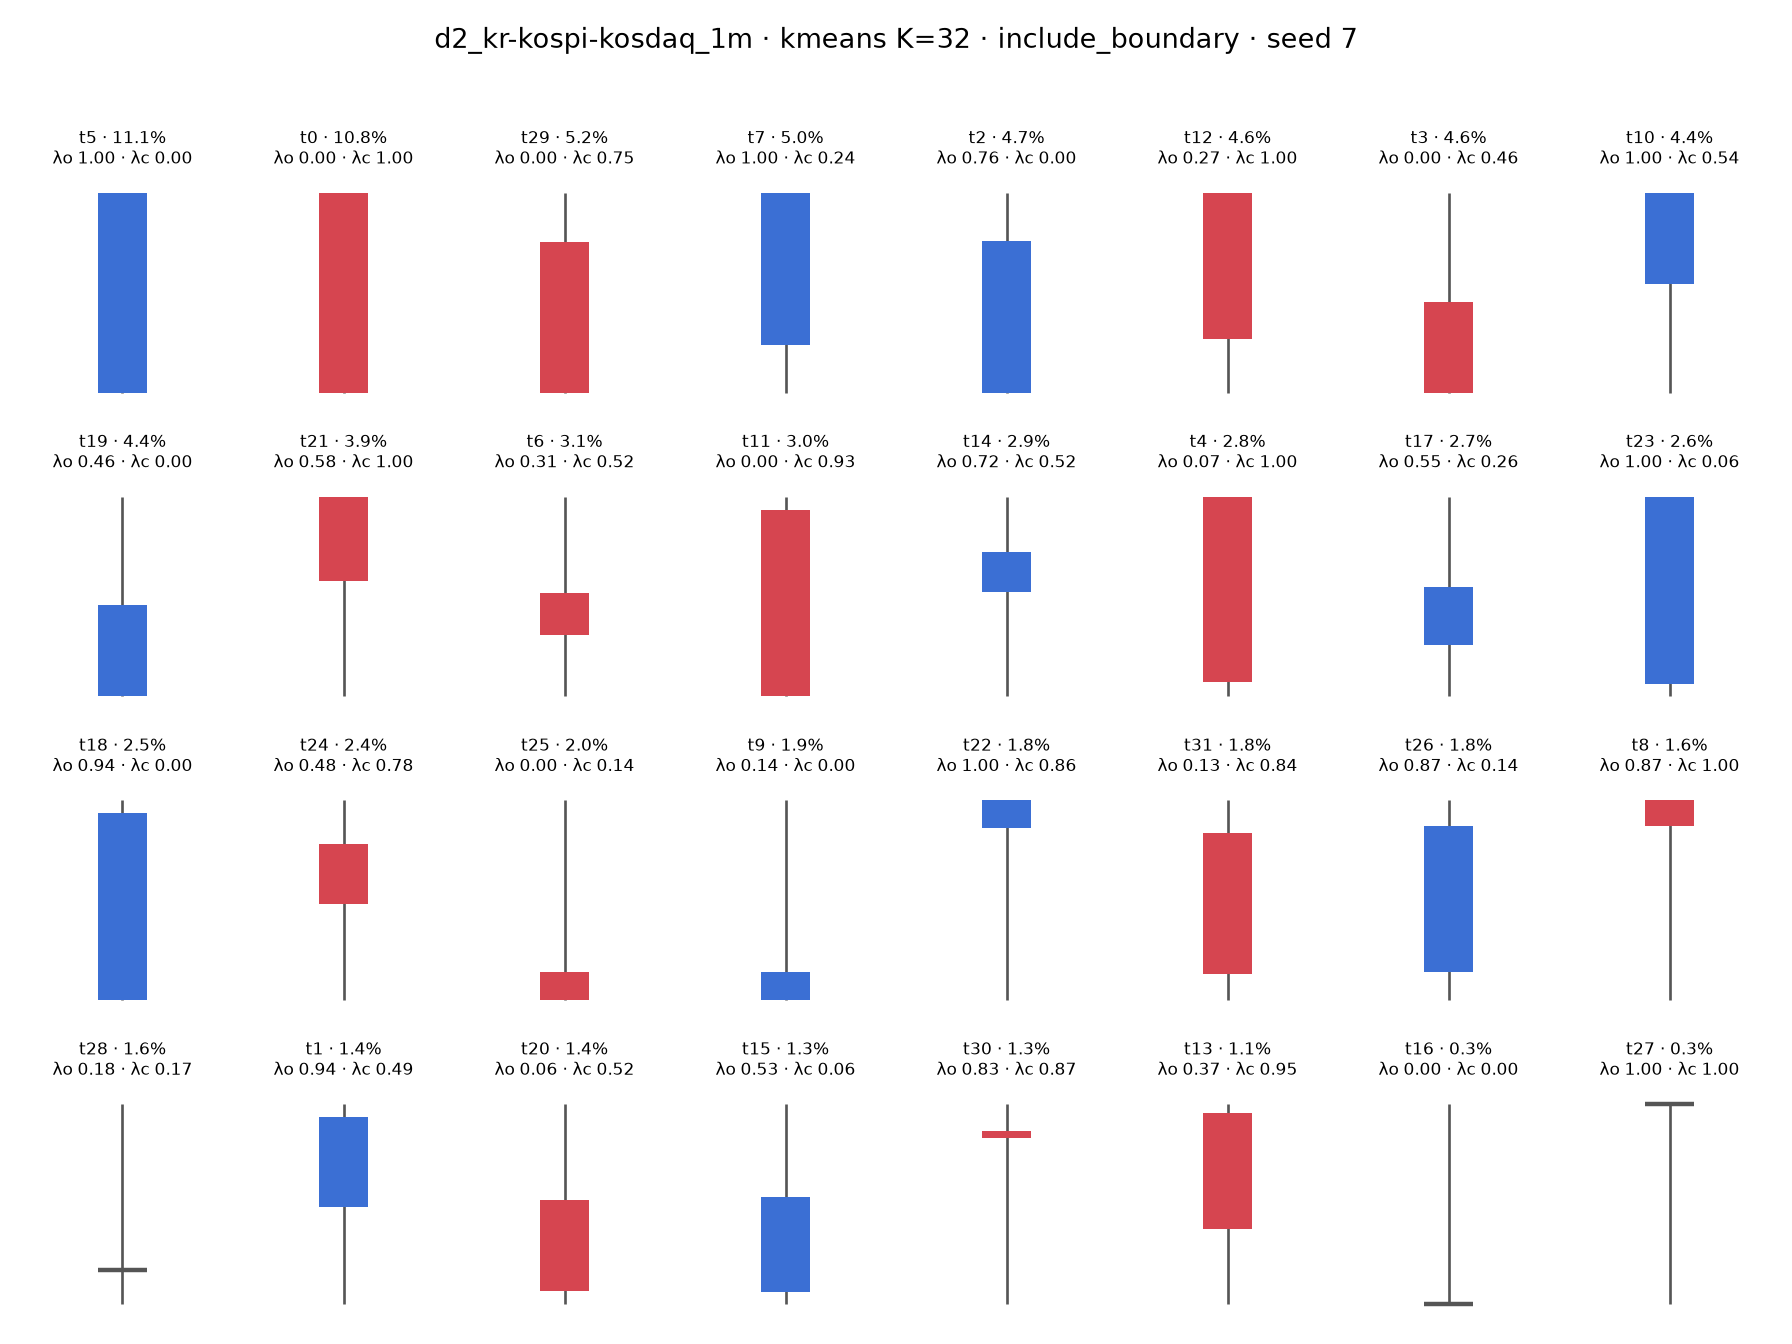

notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d2_kr-kospi-kosdaq_1m/cfg-cced087a/run-20260706-150350_seed-7/figures/token-shapes__d2_kr-kospi-kosdaq_1m__kmeans__k32-exclude_boundary__seed-7.png


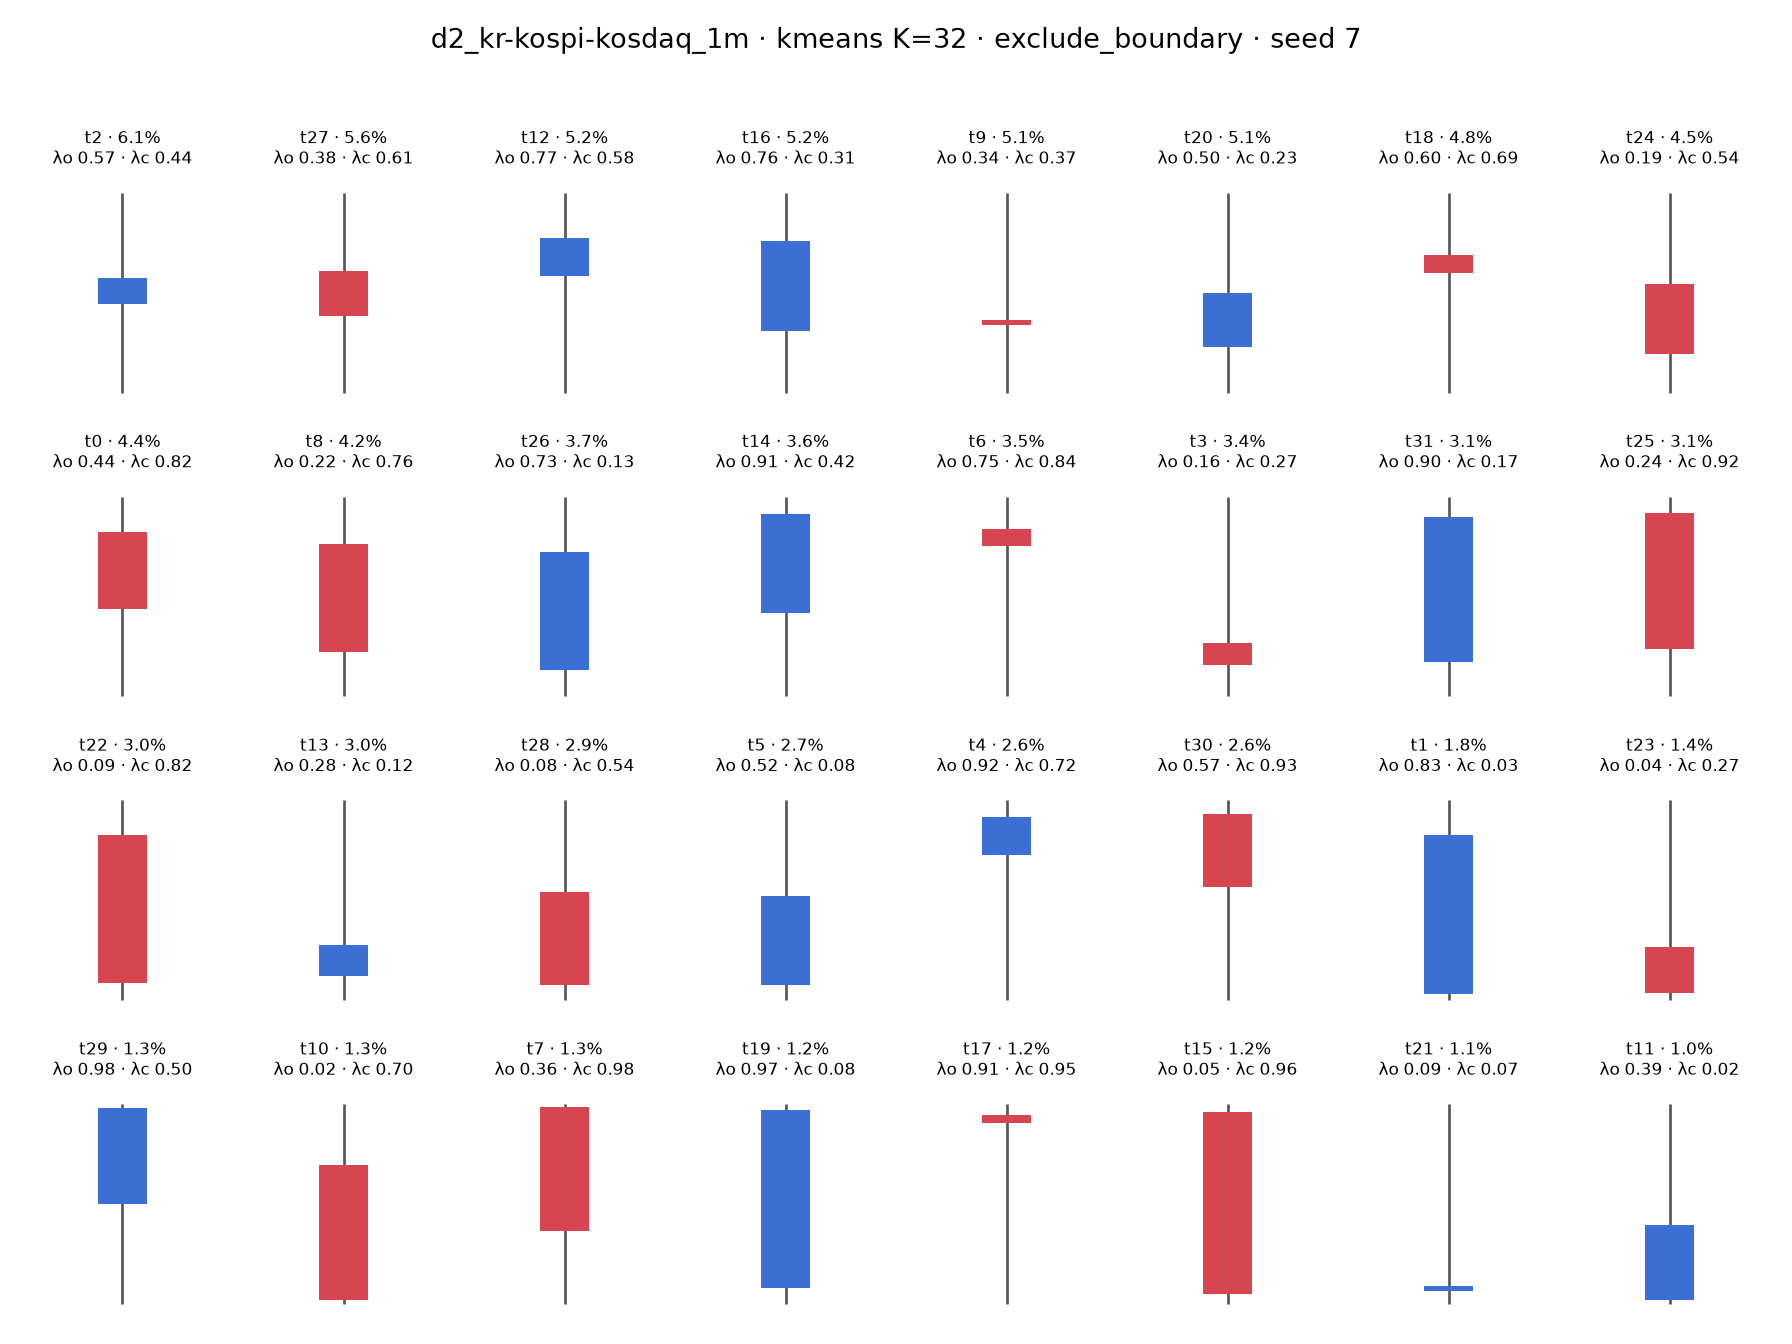

['notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_daily/cfg-d35d74f4/run-20260706-150235_seed-7/figures/token-shapes__d1_kospi_daily__kmeans__k32-include_boundary__seed-7.png',
 'notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_daily/cfg-d35d74f4/run-20260706-150235_seed-7/figures/token-shapes__d1_kospi_daily__kmeans__k32-exclude_boundary__seed-7.png',
 'notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_1m/cfg-e03165b4/run-20260706-150241_seed-7/figures/token-shapes__d1_kospi_1m__kmeans__k32-include_boundary__seed-7.png',
 'notebooks/runs/candlestick-shape-quantization/phase-01-shape-tokenizer/step-02-tokenizer-baselines/d1_kospi_1m/cfg-e03165b4/run-20260706-150241_seed-7/figures/token-shapes__d1_kospi_1m__kmeans__k32-exclude_boundary__seed-7.png',
 'notebooks/runs/candlestick-shape-quantization/phase-01-shape-t

In [6]:
import numpy as np
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from kairos.experiments.shape_tokenizer.baselines import shape_vectors

ATLAS_CODEBOOK_SIZE = max(CODEBOOK_SIZES)
ATLAS_SEED = SEEDS[0]


def _sigmoid(value: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-value))


def fit_kmeans_codebook(
    rows: list[dict[str, Any]], *, codebook_size: int, seed: int, split
) -> tuple[np.ndarray, np.ndarray]:
    """fit_kmeans와 동일한 절차로 fit한 뒤 prototype의 (lambda_o, lambda_c)와 token 점유율을 돌려준다."""
    vectors = shape_vectors(rows)
    train_vectors = vectors[split_masks(rows, split=split)["train"]]
    scaler = StandardScaler().fit(train_vectors)
    model = KMeans(n_clusters=codebook_size, random_state=seed, n_init=20)
    model.fit(scaler.transform(train_vectors))
    tokens = model.predict(scaler.transform(vectors))
    centroid_lambdas = _sigmoid(scaler.inverse_transform(model.cluster_centers_))
    token_shares = np.bincount(tokens, minlength=codebook_size) / len(tokens)
    return centroid_lambdas, token_shares


def draw_candle_glyph(ax, lambda_o: float, lambda_c: float, *, body_width: float = 0.5) -> None:
    color = "#d64550" if lambda_c >= lambda_o else "#3b6fd4"
    body_low, body_high = sorted((lambda_o, lambda_c))
    ax.vlines(0.0, 0.0, 1.0, color="#555555", linewidth=1.2, zorder=1)
    if body_high - body_low < 0.015:
        ax.hlines(
            (body_low + body_high) / 2,
            -body_width / 2,
            body_width / 2,
            color="#555555",
            linewidth=2.0,
            zorder=2,
        )
    else:
        ax.add_patch(
            plt.Rectangle(
                (-body_width / 2, body_low),
                body_width,
                body_high - body_low,
                facecolor=color,
                edgecolor="none",
                zorder=2,
            )
        )
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-0.08, 1.08)
    ax.axis("off")


def make_cluster_shape_figure(
    rows: list[dict[str, Any]], path: Path, *, title: str, codebook_size: int, seed: int, split
) -> None:
    centroid_lambdas, token_shares = fit_kmeans_codebook(
        rows, codebook_size=codebook_size, seed=seed, split=split
    )
    order = np.argsort(token_shares)[::-1]
    n_cols = 8
    n_rows = int(np.ceil(codebook_size / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 2.1))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, token in zip(np.atleast_1d(axes).ravel(), order):
        lambda_o, lambda_c = centroid_lambdas[token]
        draw_candle_glyph(ax, lambda_o, lambda_c)
        ax.set_title(
            f"t{token} · {token_shares[token]:.1%}\n"
            f"λo {lambda_o:.2f} · λc {lambda_c:.2f}",
            fontsize=7.5,
        )
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    fig.savefig(path, dpi=160)
    plt.close(fig)


CLUSTER_SHAPE_FIGURES: list[Path] = []
for result in RUN_RESULTS:
    if result["seed"] != ATLAS_SEED or result["status"] != "ok":
        continue
    feature_input = next(
        item for item in ALL_BASELINE_INPUTS if item.dataset_id == result["dataset_id"]
    )
    source_rows, _, _ = load_baseline_input(feature_input)
    split = split_protocol_for_interval(dataset_interval(feature_input.dataset_id))
    for boundary_policy in BOUNDARY_POLICIES:
        if result["policy_results"][boundary_policy]["status"] != "ok":
            continue
        rows = shape_rows_for_boundary_policy(source_rows, boundary_policy=boundary_policy)
        figure_path = Path(result["run_dir"]) / "figures" / (
            f"token-shapes__{result['dataset_id']}__kmeans"
            f"__k{ATLAS_CODEBOOK_SIZE}-{boundary_policy}__seed-{ATLAS_SEED}.png"
        )
        make_cluster_shape_figure(
            rows,
            figure_path,
            title=(
                f"{result['dataset_id']} · kmeans K={ATLAS_CODEBOOK_SIZE}"
                f" · {boundary_policy} · seed {ATLAS_SEED}"
            ),
            codebook_size=ATLAS_CODEBOOK_SIZE,
            seed=ATLAS_SEED,
            split=split,
        )
        CLUSTER_SHAPE_FIGURES.append(figure_path)

for figure_path in CLUSTER_SHAPE_FIGURES:
    print(figure_path.relative_to(PROJECT_ROOT).as_posix())
    display(Image(filename=figure_path.as_posix()))

[figure_path.relative_to(PROJECT_ROOT).as_posix() for figure_path in CLUSTER_SHAPE_FIGURES]